<a href="https://colab.research.google.com/github/Sampavi01/Hotel_Revenue_Forecasting/blob/forecasting/Model_Training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [54]:
# --- Imports & Constants ---
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.linear_model import Ridge
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import RobustScaler
from datetime import timedelta
import matplotlib.pyplot as plt
import os

# Paths & scope
OUTPUT_FILE_NAME = 'Model_Training_Datasets.xlsx'
TEST_SET_DAYS = 60    # Last 2 months for final evaluation

# Optimization Constants
MAPE_EPSILON = 1e-6    # Prevents division by zero in MAPE
MIN_TRAIN_DAYS = 180   # Minimum required data length for stable CV training

# Targets (raw only)
TARGET_RAW_COLS = ['Revenue_By_BreakFast', 'Revenue_By_Dinner', 'Revenue_By_Lunch']

# Features
LAG_DAYS = [1, 7, 14]
ROLL_WINDOWS = [7]

# Cross-validation Defaults
N_SPLITS = 2           # Default number of TimeSeriesSplit folds
VAL_DAYS = 90          # Default size of validation window per fold

# Storage
test_predictions_list = []
ensemble_metrics = []
feature_importance_dict = {}
cv_results_list = []

In [55]:
# --- Utility Functions ---

def add_lag_and_rolling(df, target_cols, lag_days, roll_windows):
    """Adds lag and rolling features for target columns."""
    for col in target_cols:
        for lag in lag_days:
            df[f'{col}_lag{lag}'] = df[col].shift(lag)
        if pd.api.types.is_numeric_dtype(df[col]):
            for w in roll_windows:
                # Rolling mean/std shifted by 1 day to prevent data leakage
                df[f'{col}_rollmean{w}'] = df[col].rolling(window=w, min_periods=1).mean().shift(1)
                df[f'{col}_rollstd{w}'] = df[col].rolling(window=w, min_periods=1).std().shift(1).fillna(0)
    df.fillna(0, inplace=True)
    return df

def dynamic_weights(y_val_raw, y_pred_xgb, y_pred_ridge):
    """Computes fold-specific ensemble weights via validation RMSE."""
    rmse_xgb = np.sqrt(mean_squared_error(y_val_raw, y_pred_xgb))
    rmse_ridge = np.sqrt(mean_squared_error(y_val_raw, y_pred_ridge))
    total = rmse_xgb + rmse_ridge if (rmse_xgb + rmse_ridge) > 0 else 1.0
    w_xgb = 1 - (rmse_xgb / total)
    w_ridge = 1 - w_xgb
    return w_xgb, w_ridge

def plot_test_results(test_df, center_name, meal_period):
    """Plots actual vs. predicted revenue for the test set."""
    plt.figure(figsize=(12, 6))
    plt.plot(test_df['Date'], test_df['Actual_Revenue'], label='Actual Revenue', marker='o', linestyle='-')
    plt.plot(test_df['Date'], test_df['Predicted_Revenue'], label='Predicted Revenue', marker='x', linestyle='--')
    plt.title(f'Actual vs. Predicted Revenue (Test Set) - {center_name} - {meal_period}')
    plt.xlabel('Date'); plt.ylabel('Revenue')
    plt.legend(); plt.grid(True, alpha=0.5); plt.xticks(rotation=45)
    plt.tight_layout(); plt.show()

def plot_residuals_over_time(residuals_df, center_name, meal_period):
    """Plots the residuals (Actual - Predicted) over the test time period."""
    residuals_df = residuals_df.copy()
    residuals_df['Residual'] = residuals_df['Actual_Revenue'] - residuals_df['Predicted_Revenue']
    plt.figure(figsize=(12, 5))
    plt.plot(residuals_df['Date'], residuals_df['Residual'], marker='.', linestyle='None', alpha=0.6)
    plt.axhline(0, color='red', linestyle='--', linewidth=1)
    mean_residual = residuals_df['Residual'].mean()
    plt.axhline(mean_residual, color='blue', linestyle='-', linewidth=1, label=f'Mean Residual: {mean_residual:.2f}')
    plt.title(f'Test Set Residuals Over Time - {center_name} - {meal_period}')
    plt.xlabel('Date'); plt.ylabel('Residual (Actual - Predicted)')
    plt.legend(); plt.grid(True, alpha=0.5); plt.xticks(rotation=45)
    plt.tight_layout(); plt.show()

def plot_cv_rmse_comparison(cv_results_list):
    """Compares the RMSE for all folds across all centers/meals for robustness check."""
    df_cv = pd.DataFrame(cv_results_list)
    if df_cv.empty:
        print("No CV results to plot.")
        return
    df_cv['Center_Meal'] = df_cv['Center'].astype(str) + ' - ' + df_cv['Meal']
    df_pivot = df_cv.pivot(index='Center_Meal', columns='Fold', values='RMSE')
    plt.figure(figsize=(14, 7))
    df_pivot.plot(kind='bar', figsize=(14, 7), width=0.8)
    plt.title('Fold-by-Fold RMSE Comparison Across All Models')
    plt.ylabel('RMSE (Raw Scale)')
    plt.xlabel('Revenue Center - Meal Period')
    plt.xticks(rotation=45, ha='right'); plt.legend(title='CV Fold')
    plt.grid(axis='y', alpha=0.5); plt.tight_layout(); plt.show()

In [56]:
# --- Main Training Function with xgb.train early stopping ---

def train_and_forecast_center(df_center, center_name):
    """
    Splits data into Train/Test, runs CV and Early Stopping on Train,
    and performs final evaluation on the Test set.
    """
    # 1) Feature engineering
    df_center = add_lag_and_rolling(df_center, TARGET_RAW_COLS, LAG_DAYS, ROLL_WINDOWS)

    # 2) Train/Test split by date
    max_date = df_center['Date'].max()
    test_start_date = max_date - timedelta(days=TEST_SET_DAYS)
    df_train_full = df_center[df_center['Date'] < test_start_date].copy()
    df_test_full = df_center[df_center['Date'] >= test_start_date].copy()

    if df_train_full.empty or df_test_full.empty:
        print(f"ERROR: Center {center_name} data is insufficient for split.")
        return

    # 3) Dynamic CV adjustment based on training length
    data_length = len(df_train_full)
    if data_length < (MIN_TRAIN_DAYS + VAL_DAYS * N_SPLITS):
        new_val_days = max(15, int(data_length * 0.1))
        new_n_splits = max(1, int((data_length - new_val_days) / MIN_TRAIN_DAYS))
        tscv = TimeSeriesSplit(n_splits=new_n_splits, test_size=new_val_days)
        print(f"⚠️ Adjusted CV for small data ({center_name}): n_splits={new_n_splits}, test_size={new_val_days}")
    else:
        tscv = TimeSeriesSplit(n_splits=N_SPLITS, test_size=VAL_DAYS)

    # 4) Features and target setup
    feature_cols = [c for c in df_center.columns if c not in ['Date'] + TARGET_RAW_COLS]
    numeric_features = [c for c in feature_cols if pd.api.types.is_numeric_dtype(df_center[c])]
    categorical_features = [c for c in feature_cols if c not in numeric_features]
    X_train_full = df_train_full[feature_cols]
    Y_train_full = df_train_full[TARGET_RAW_COLS]

    # Fixed base params (you can later grid-search these if needed)
    base_params = {
        'objective': 'reg:squarederror',
        'learning_rate': 0.005,
        'max_depth': 3,
        'subsample': 0.8,
        'colsample_bytree': 0.8,
        'seed': 42
    }

    # 5) CV, early stopping, ensemble
    for raw_target_col in TARGET_RAW_COLS:
        meal_period = raw_target_col.replace('Revenue_By_', '')
        last_model_xgb = None
        last_model_ridge = None
        last_weights = (0.5, 0.5)

        for fold, (train_idx, val_idx) in enumerate(tscv.split(X_train_full)):
            # Split fold data
            X_train_cv, X_val = X_train_full.iloc[train_idx], X_train_full.iloc[val_idx]
            Y_train_cv, Y_val = Y_train_full.iloc[train_idx][raw_target_col], Y_train_full.iloc[val_idx][raw_target_col]

            # Scale numeric features per fold
            scaler = RobustScaler()
            X_train_num = pd.DataFrame(scaler.fit_transform(X_train_cv[numeric_features]), columns=numeric_features, index=X_train_cv.index)
            X_val_num = pd.DataFrame(scaler.transform(X_val[numeric_features]), columns=numeric_features, index=X_val.index)
            X_train_cv_scaled = pd.concat([X_train_num, X_train_cv[categorical_features]], axis=1)
            X_val_scaled = pd.concat([X_val_num, X_val[categorical_features]], axis=1)

            # DMatrix with explicit feature names for compatibility
            dtrain = xgb.DMatrix(
                X_train_cv_scaled.values, label=Y_train_cv, feature_names=list(X_train_cv_scaled.columns)
            )
            dval = xgb.DMatrix(
                X_val_scaled.values, label=Y_val, feature_names=list(X_val_scaled.columns)
            )

            # Train XGB with early stopping (works across older versions)
            es_xgb_model = xgb.train(
                base_params,
                dtrain,
                num_boost_round=5000,
                evals=[(dval, 'validation')],
                early_stopping_rounds=100,
                verbose_eval=False
            )

            # Predict on validation
            y_pred_xgb = es_xgb_model.predict(dval)

            # Ridge on same scaled features
            best_ridge_model = Ridge(alpha=1.0, random_state=42).fit(X_train_cv_scaled, Y_train_cv)
            y_pred_ridge = best_ridge_model.predict(X_val_scaled)

            # Ensemble weights and metrics
            w_xgb, w_ridge = dynamic_weights(Y_val, y_pred_xgb, y_pred_ridge)
            y_pred_val_ens = (w_xgb * y_pred_xgb) + (w_ridge * y_pred_ridge)
            rmse = np.sqrt(mean_squared_error(Y_val, y_pred_val_ens))

            cv_results_list.append({'Center': center_name, 'Meal': meal_period, 'Fold': fold + 1, 'RMSE': rmse})
            last_model_xgb, last_model_ridge = es_xgb_model, best_ridge_model
            last_weights = (w_xgb, w_ridge)

            # Feature importance from booster (weight = split count)
            if fold == tscv.n_splits - 1:
                fi = es_xgb_model.get_score(importance_type='weight')
                # Align importance to ordered feature names
                fi_series = pd.Series(fi).sort_values(ascending=False)
                feature_importance_dict[f'{center_name}_{meal_period}'] = fi_series

        # 6) Final training on full training set using best iteration
        final_scaler = RobustScaler()
        X_train_full_num = pd.DataFrame(final_scaler.fit_transform(X_train_full[numeric_features]), columns=numeric_features, index=X_train_full.index)
        X_train_final = pd.concat([X_train_full_num, df_train_full[categorical_features]], axis=1)

        # Determine num_boost_round from early stopping
        num_round = getattr(last_model_xgb, 'best_iteration', None)
        if num_round is None:
            num_round = getattr(last_model_xgb, 'best_ntree_limit', None)
        if num_round is None:
            num_round = 500  # safe fallback

        dtrain_full = xgb.DMatrix(
            X_train_final.values, label=Y_train_full[raw_target_col], feature_names=list(X_train_final.columns)
        )
        final_xgb_model = xgb.train(
            base_params,
            dtrain_full,
            num_boost_round=num_round,
            verbose_eval=False
        )

        final_ridge_model = Ridge(alpha=last_model_ridge.alpha, random_state=42).fit(X_train_final, Y_train_full[raw_target_col])

        # 7) Test preparation and evaluation
        X_test_num = pd.DataFrame(final_scaler.transform(df_test_full[numeric_features]), columns=numeric_features, index=df_test_full.index)
        X_test = pd.concat([X_test_num, df_test_full[categorical_features]], axis=1)
        dtest = xgb.DMatrix(X_test.values, feature_names=list(X_test.columns))
        Y_test_current = df_test_full[raw_target_col]

        y_test_xgb = final_xgb_model.predict(dtest)
        y_test_ridge = final_ridge_model.predict(X_test)
        w_xgb, w_ridge = last_weights
        y_test_ens = (w_xgb * y_test_xgb) + (w_ridge * y_test_ridge)

        test_rmse = np.sqrt(mean_squared_error(Y_test_current, y_test_ens))
        test_mape = np.mean(np.abs(Y_test_current - y_test_ens) / np.maximum(Y_test_current, MAPE_EPSILON)) * 100

        print(f"\n--- FINAL TEST SET RESULTS ({center_name} - {meal_period}) ---")
        print(f"TEST RMSE: {test_rmse:.2f}, TEST MAPE: {test_mape:.2f}%")

        plot_df = pd.DataFrame({
            'Date': df_test_full['Date'],
            'Actual_Revenue': Y_test_current,
            'Predicted_Revenue': y_test_ens
        })
        test_predictions_list.append(plot_df.assign(Revenue_Center=center_name, Meal_Period=meal_period))
        plot_test_results(plot_df, center_name, meal_period)
        plot_residuals_over_time(plot_df, center_name, meal_period)

--- STARTING EXECUTION ---
✅ SUCCESS: Loaded 9 revenue centers (sheets).

--- FINAL TEST SET RESULTS (1 - BreakFast) ---
TEST RMSE: 595.65, TEST MAPE: 2326756718.69%


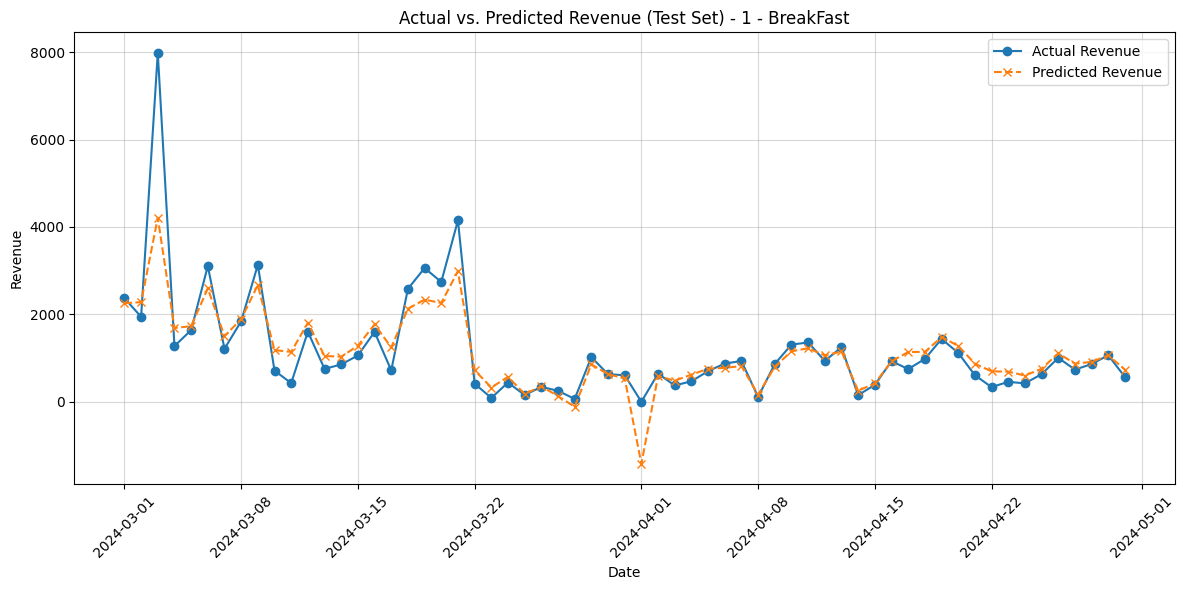

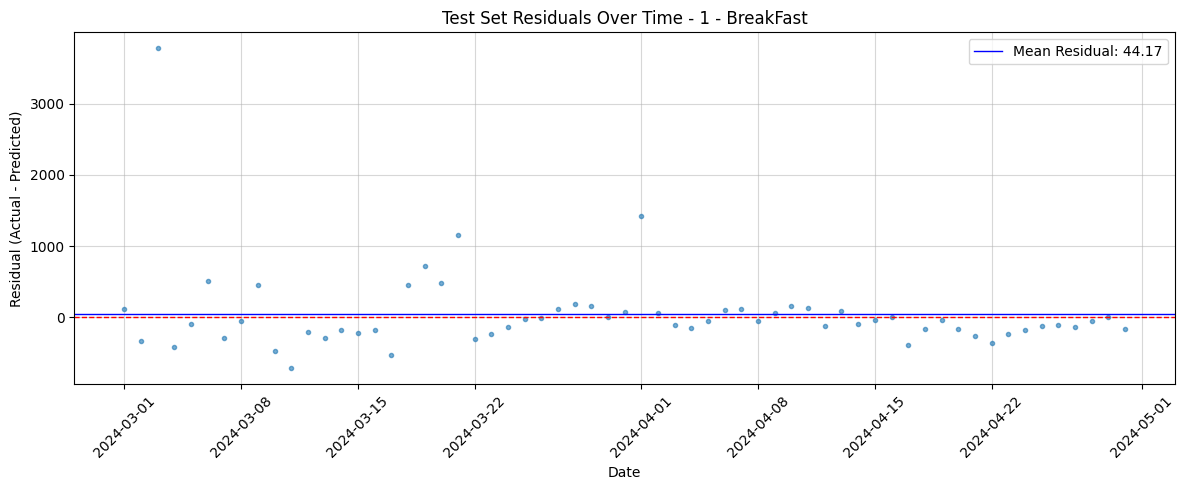


--- FINAL TEST SET RESULTS (1 - Dinner) ---
TEST RMSE: 403.55, TEST MAPE: 10.43%


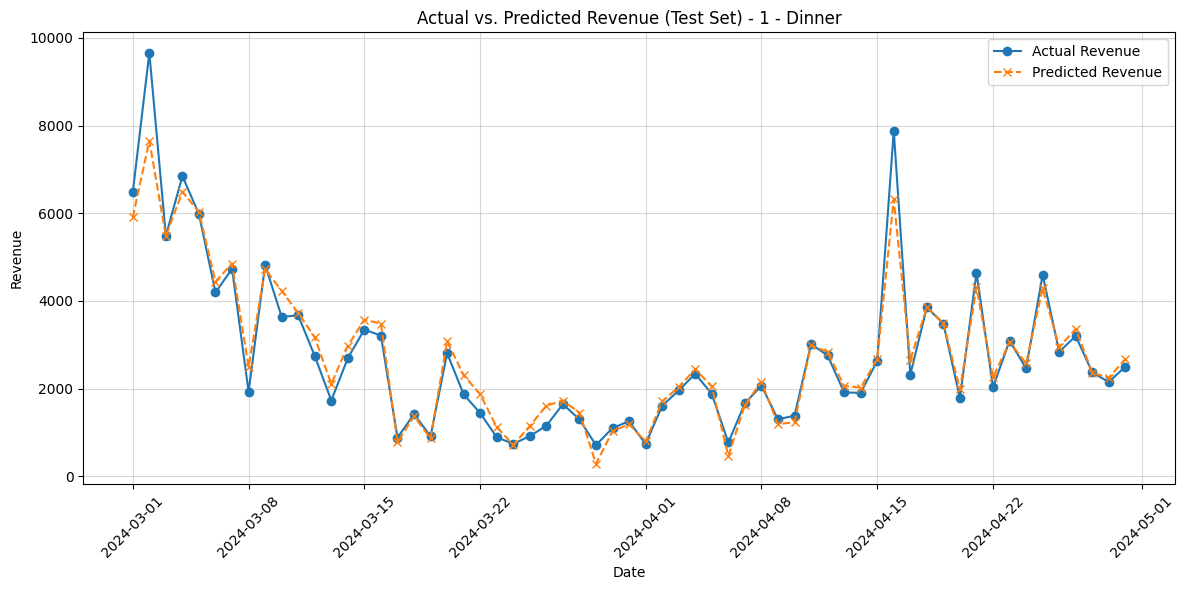

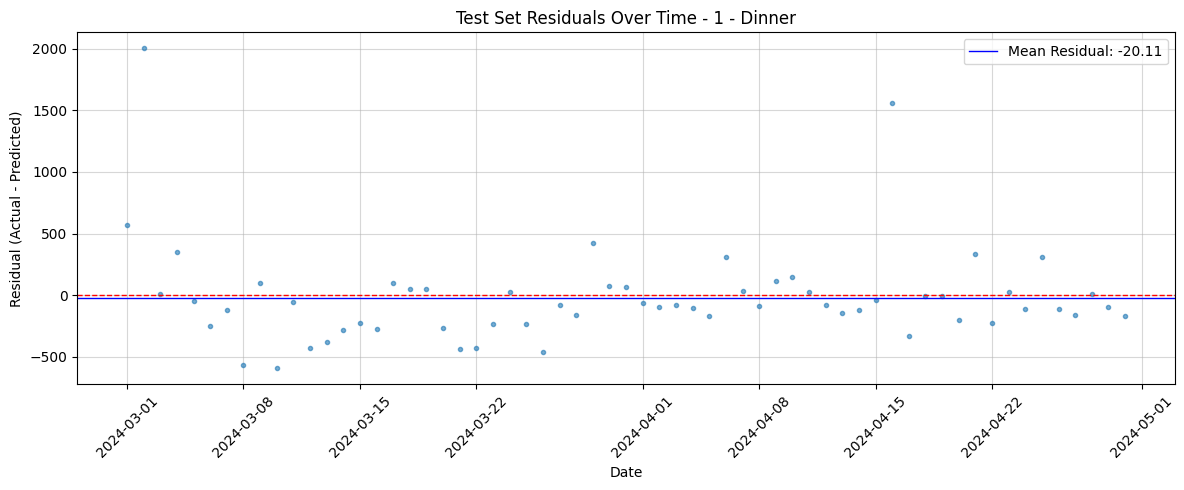


--- FINAL TEST SET RESULTS (1 - Lunch) ---
TEST RMSE: 214.35, TEST MAPE: 1400535468.81%


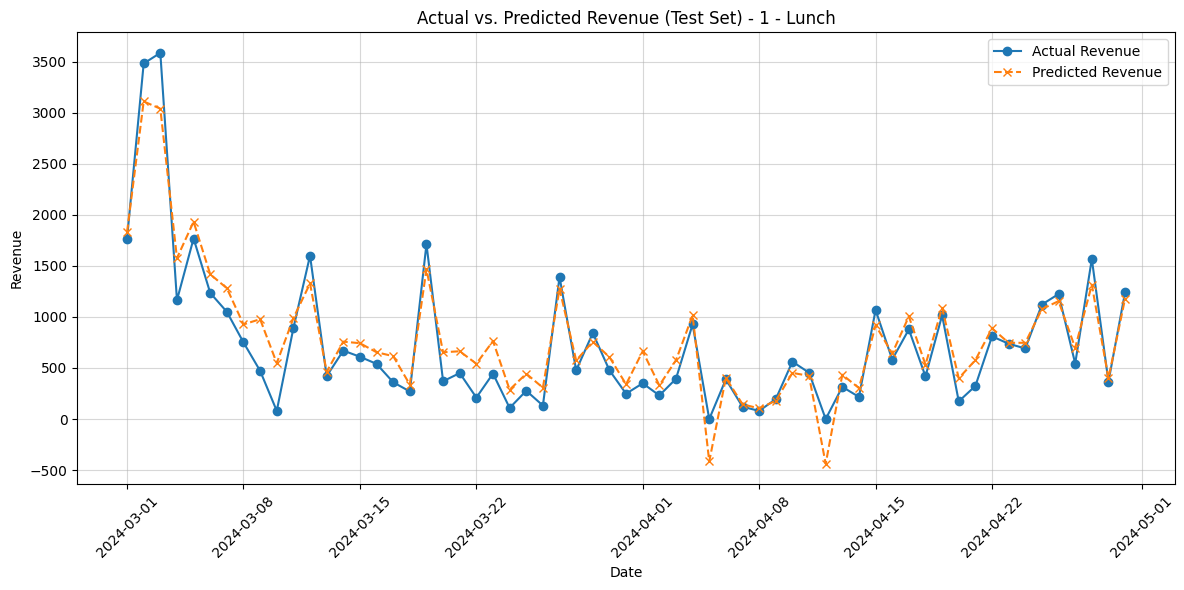

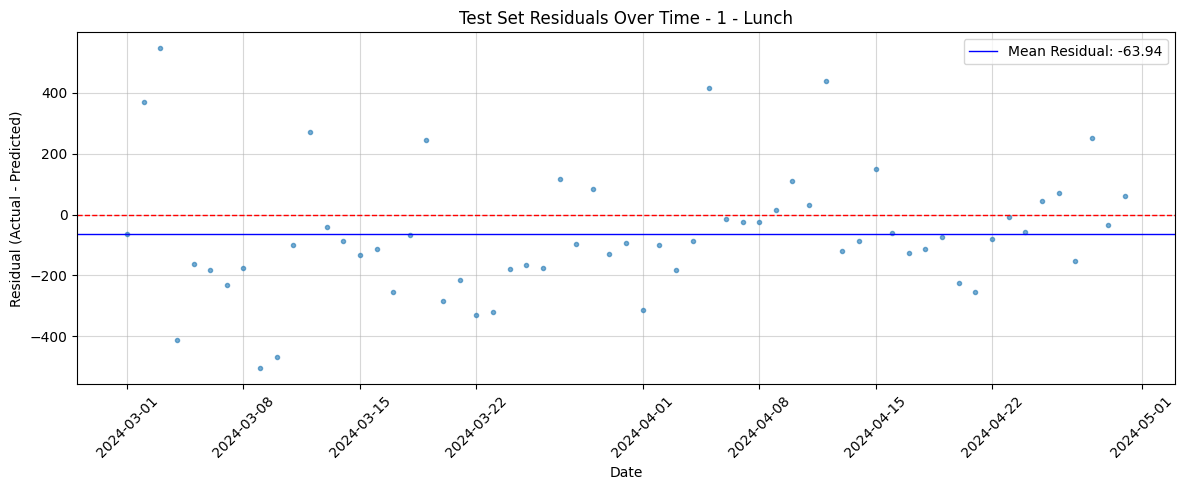


--- FINAL TEST SET RESULTS (2 - BreakFast) ---
TEST RMSE: 151.74, TEST MAPE: 795829712.13%


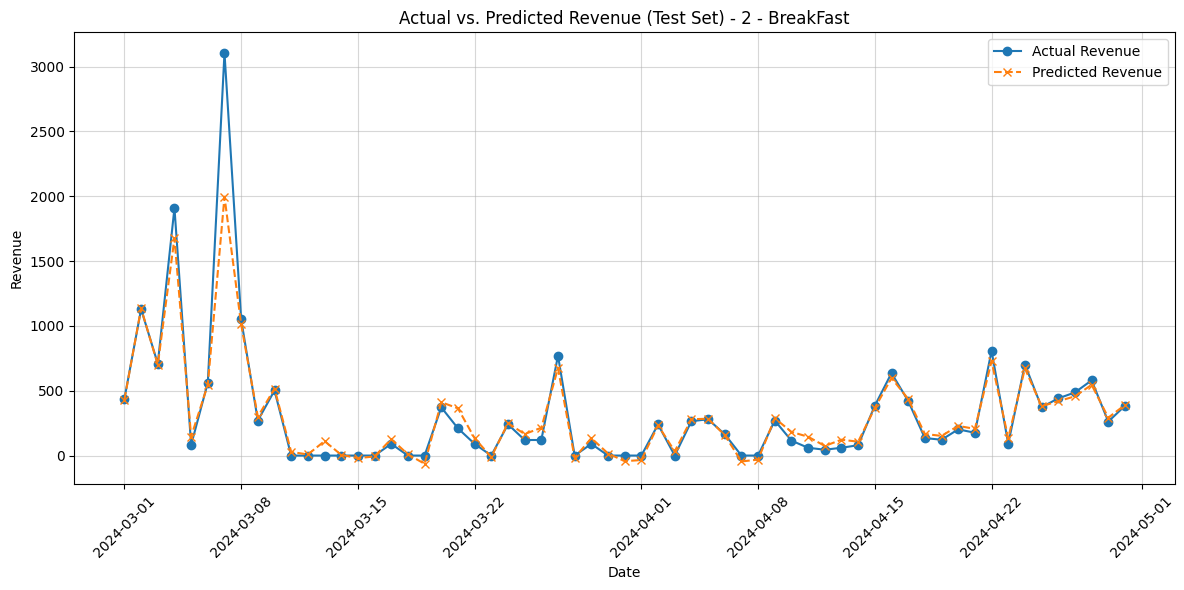

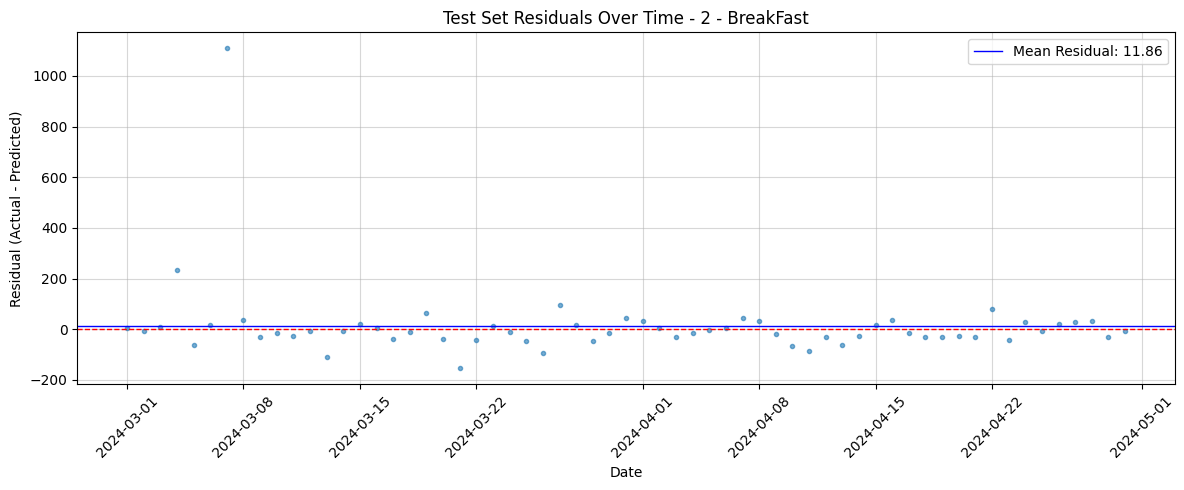


--- FINAL TEST SET RESULTS (2 - Dinner) ---
TEST RMSE: 532.34, TEST MAPE: 5980867716.53%


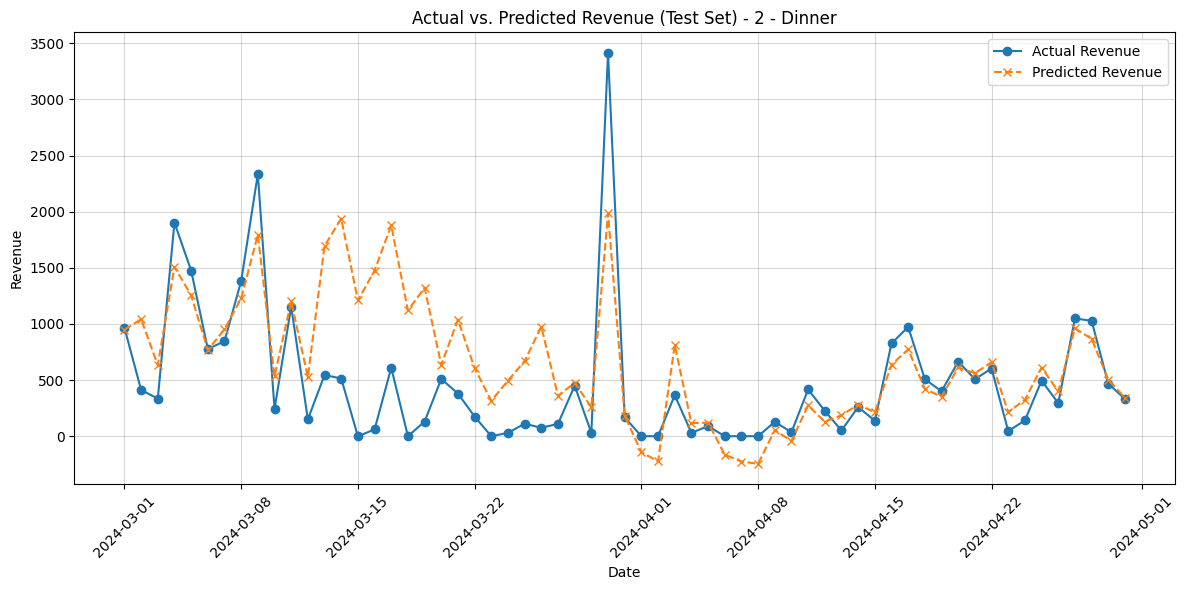

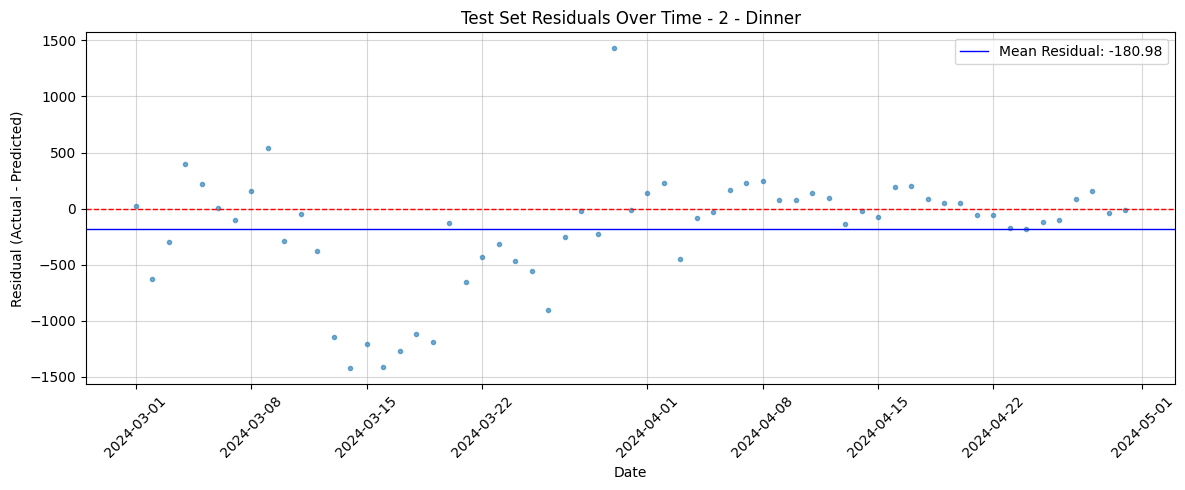


--- FINAL TEST SET RESULTS (2 - Lunch) ---
TEST RMSE: 628.14, TEST MAPE: 952290003.77%


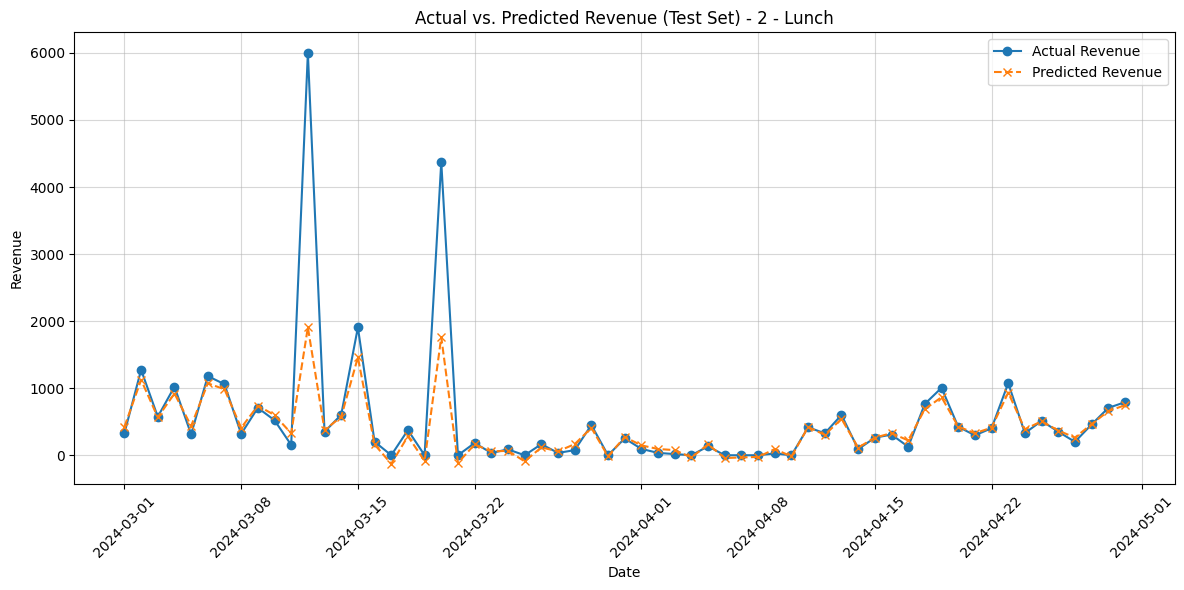

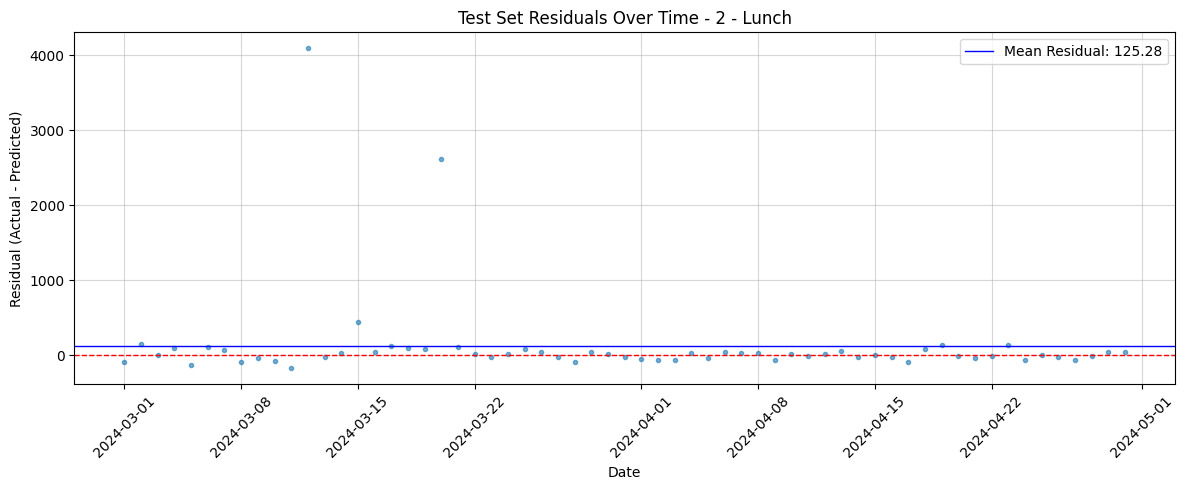


--- FINAL TEST SET RESULTS (3 - BreakFast) ---
TEST RMSE: 52.93, TEST MAPE: 502312955.09%


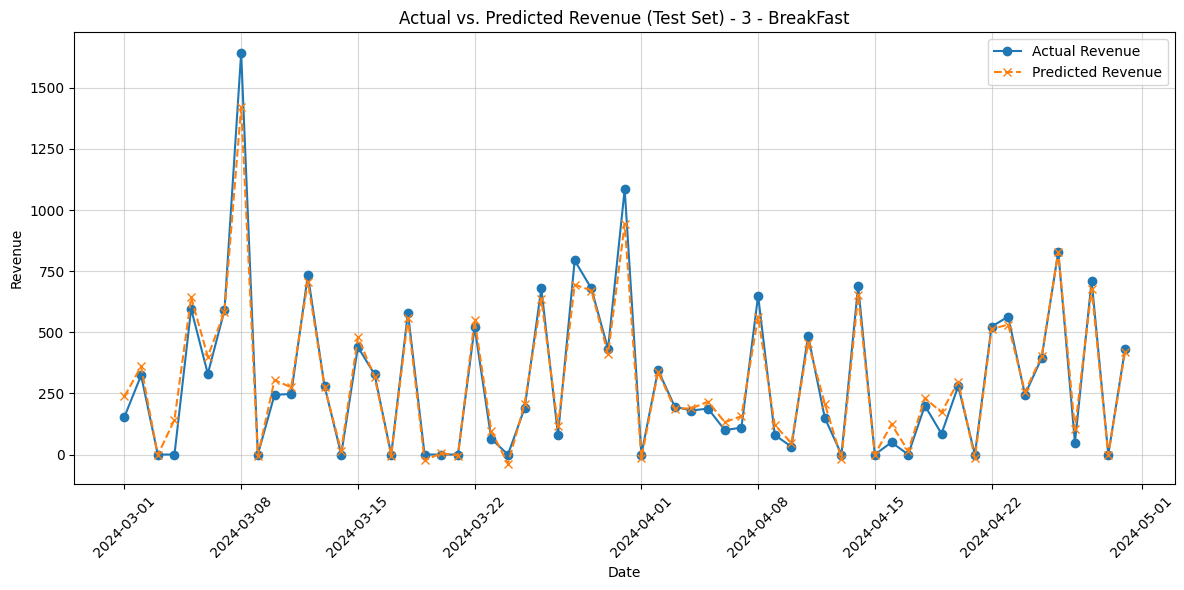

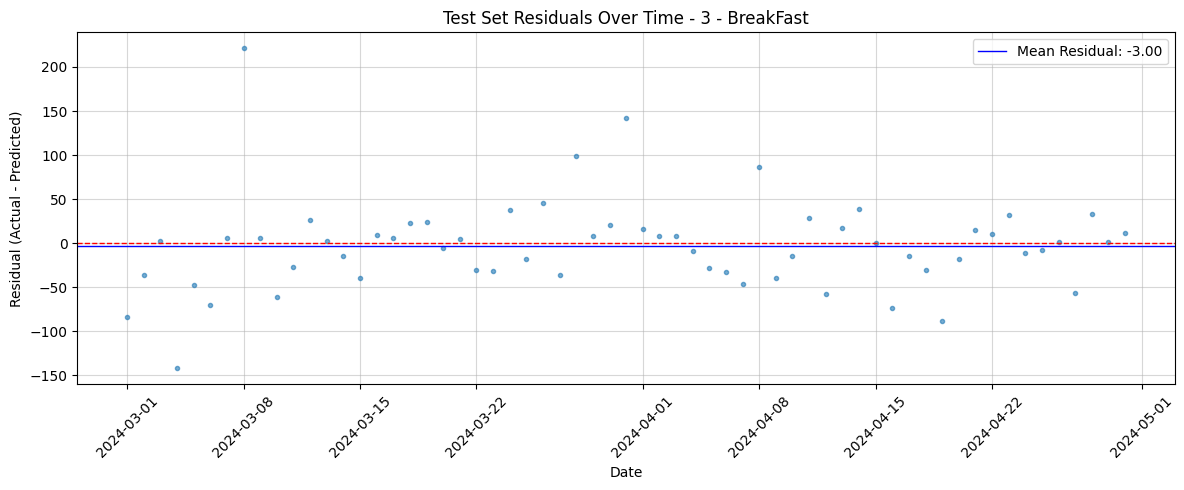


--- FINAL TEST SET RESULTS (3 - Dinner) ---
TEST RMSE: 6273.92, TEST MAPE: 9.61%


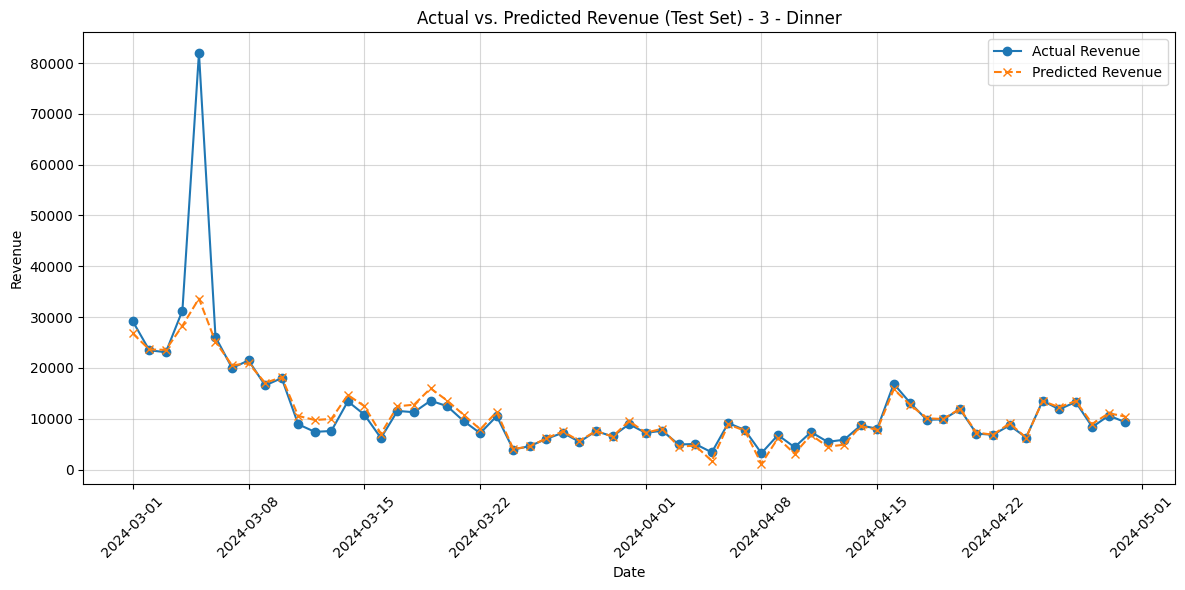

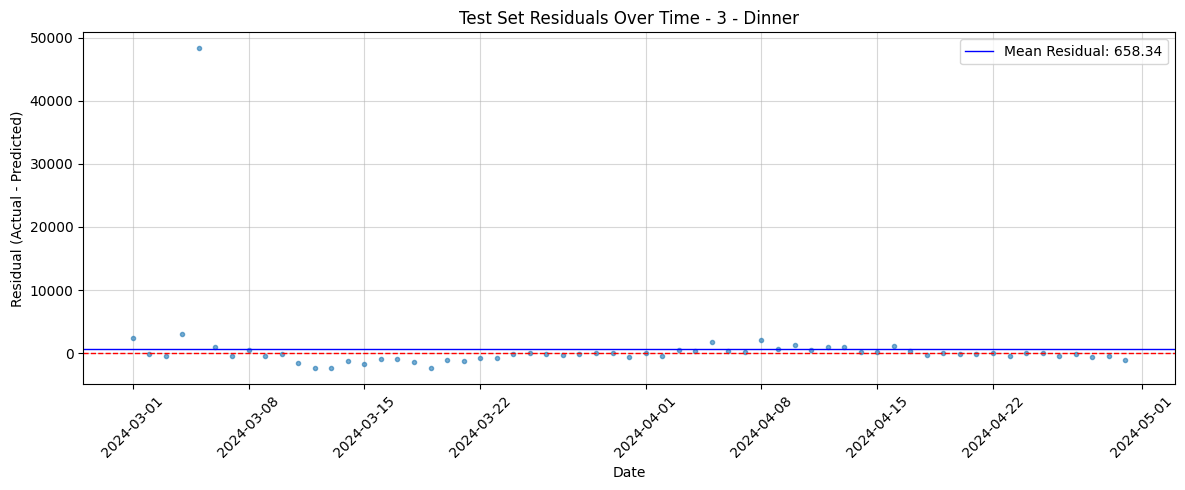


--- FINAL TEST SET RESULTS (3 - Lunch) ---
TEST RMSE: 211.83, TEST MAPE: 8.07%


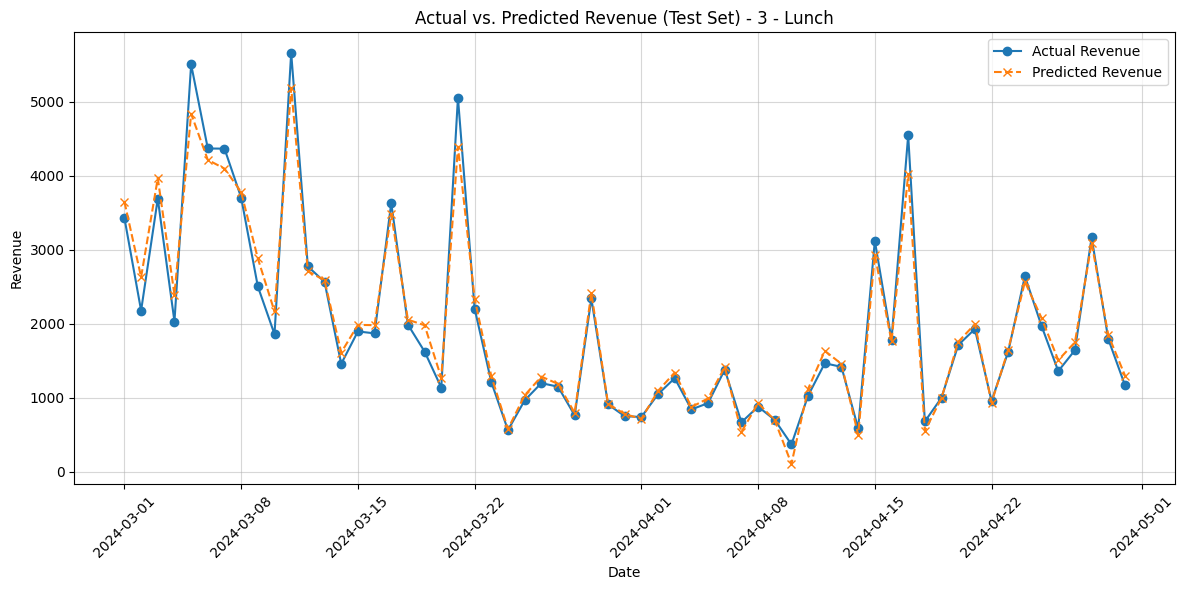

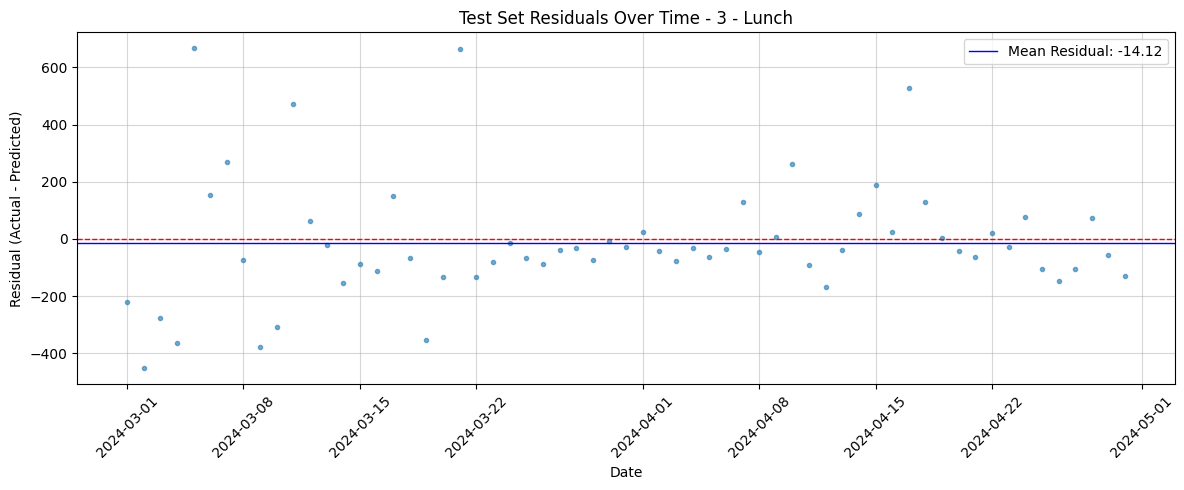


--- FINAL TEST SET RESULTS (4 - BreakFast) ---
TEST RMSE: 0.50, TEST MAPE: 50000000.00%


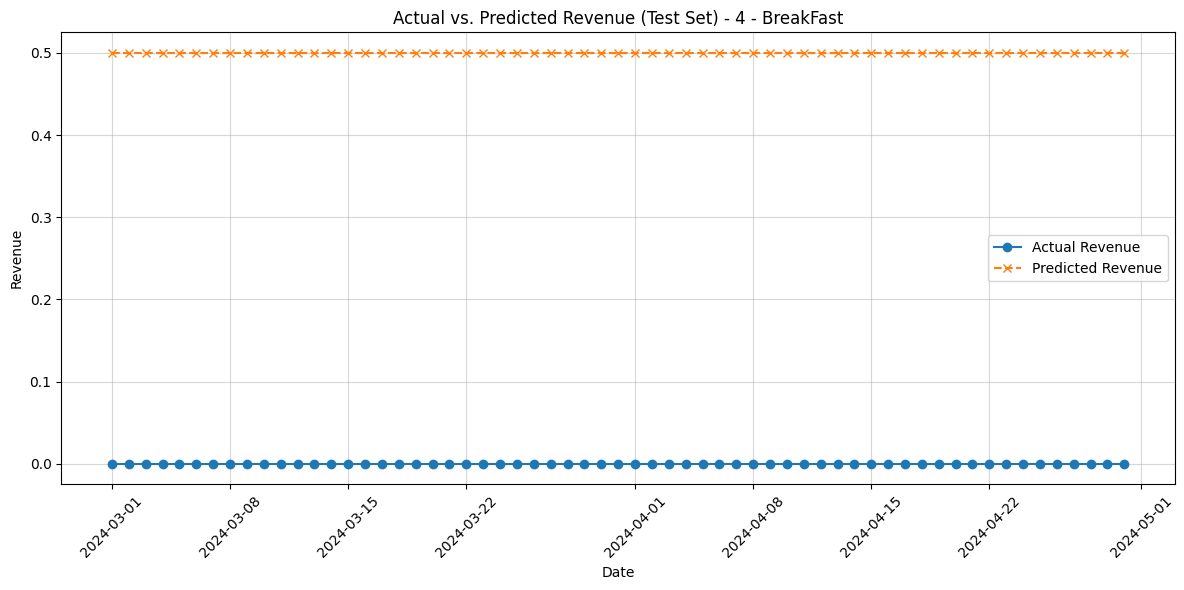

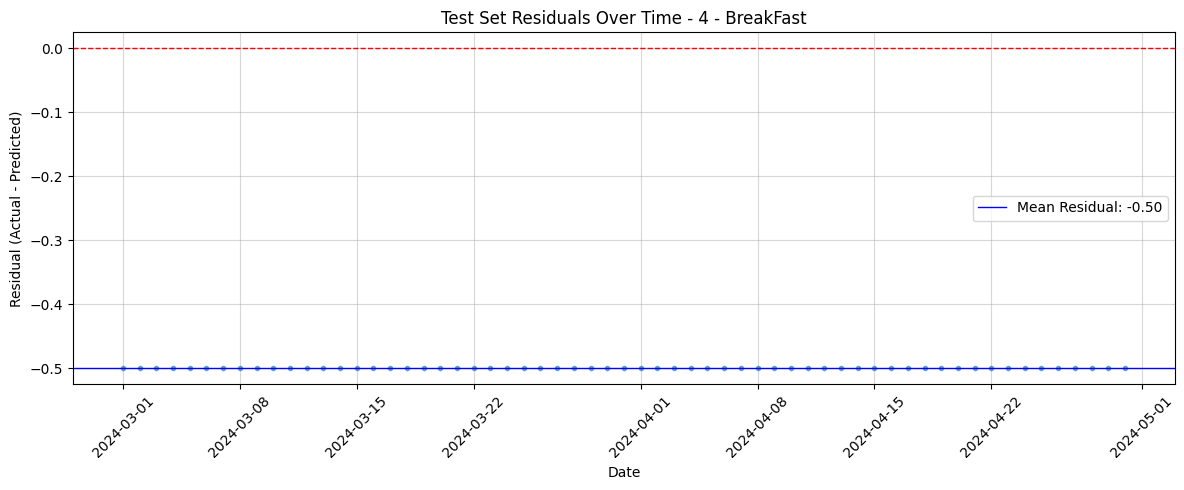


--- FINAL TEST SET RESULTS (4 - Dinner) ---
TEST RMSE: 0.00, TEST MAPE: 3178.22%


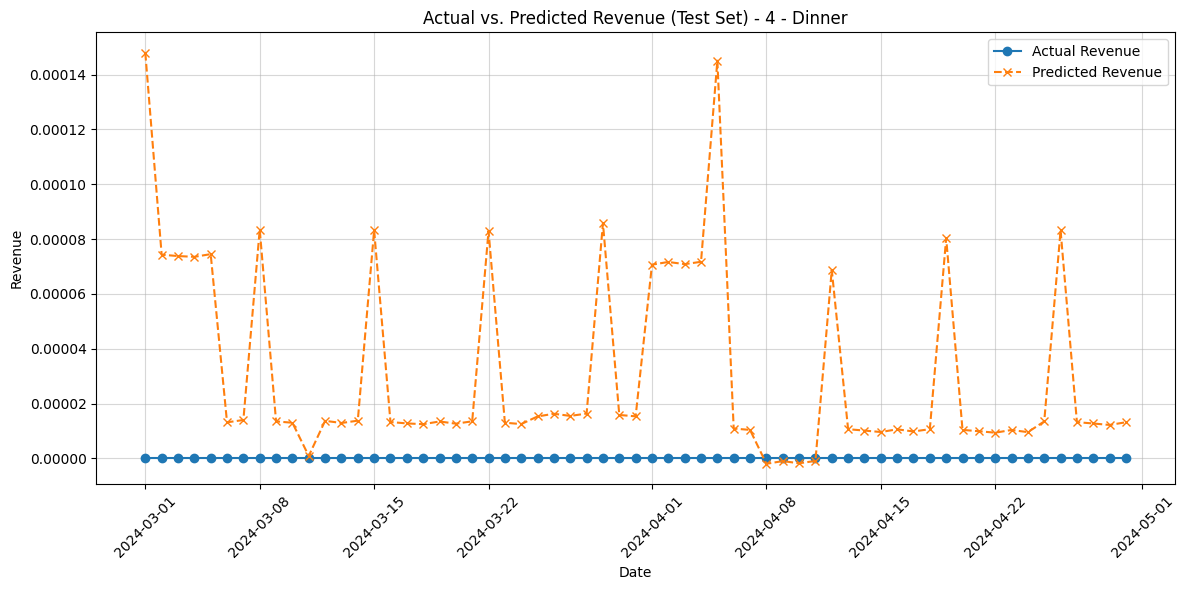

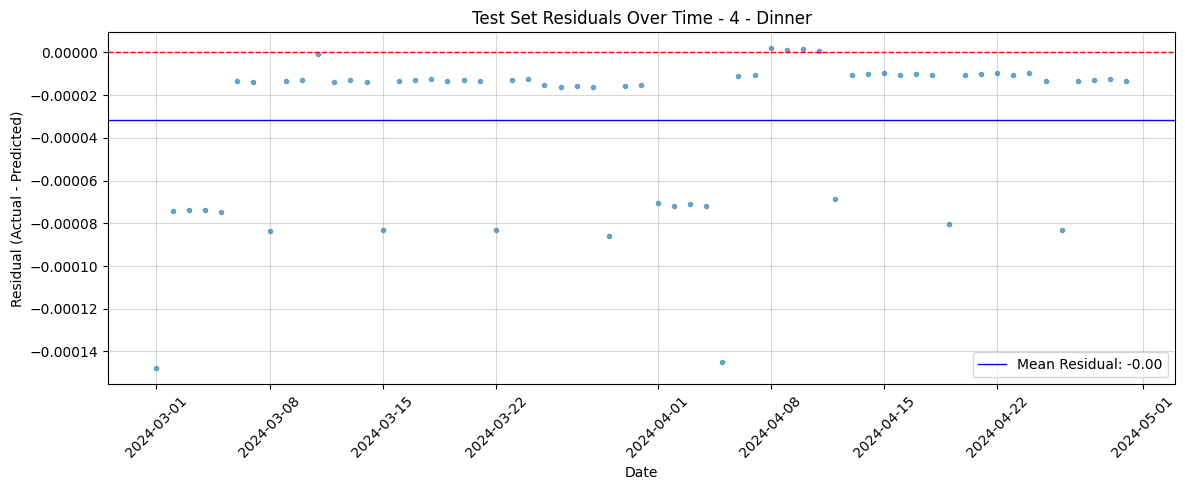


--- FINAL TEST SET RESULTS (4 - Lunch) ---
TEST RMSE: 0.50, TEST MAPE: 50000000.00%


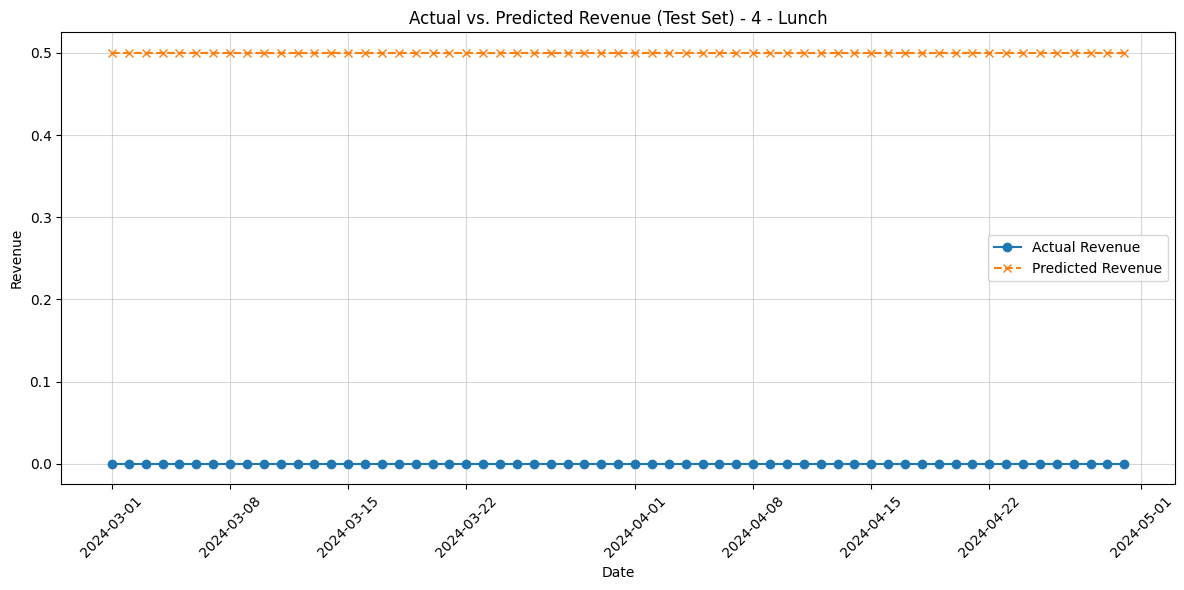

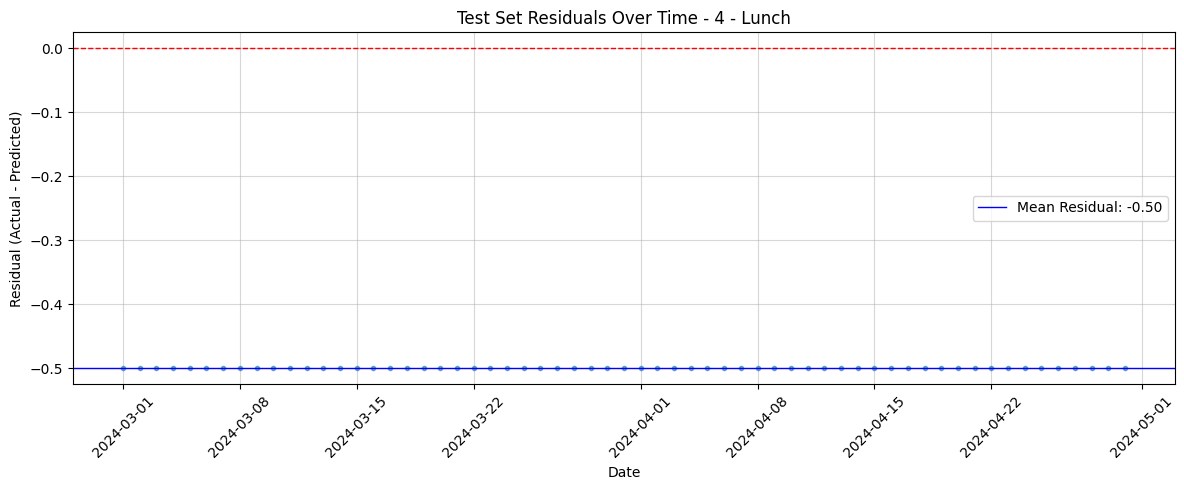


--- FINAL TEST SET RESULTS (5 - BreakFast) ---
TEST RMSE: 917.68, TEST MAPE: 4.41%


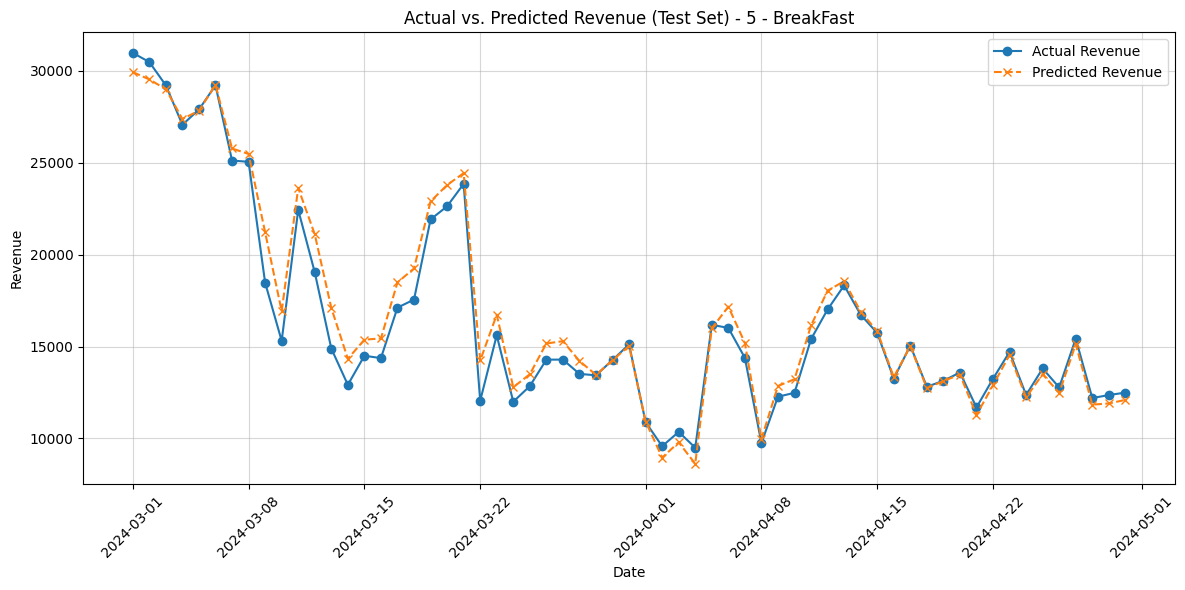

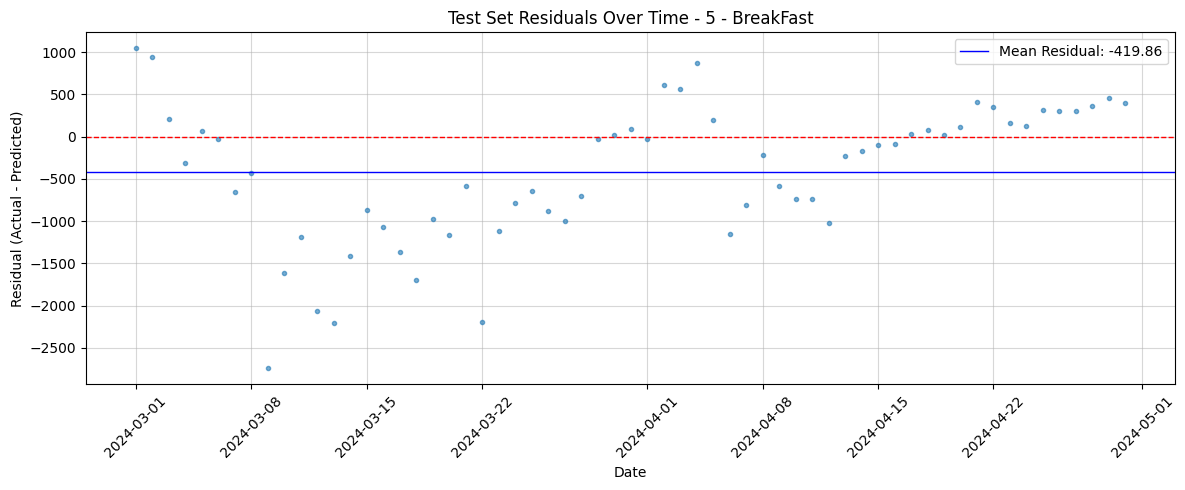


--- FINAL TEST SET RESULTS (5 - Dinner) ---
TEST RMSE: 3493.91, TEST MAPE: 16.55%


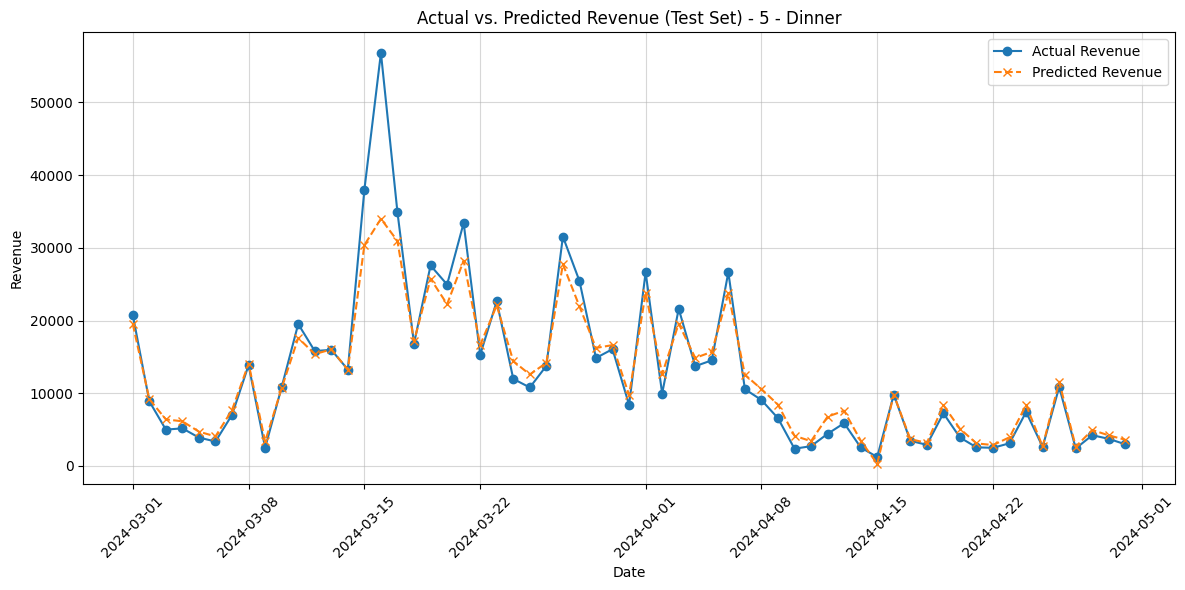

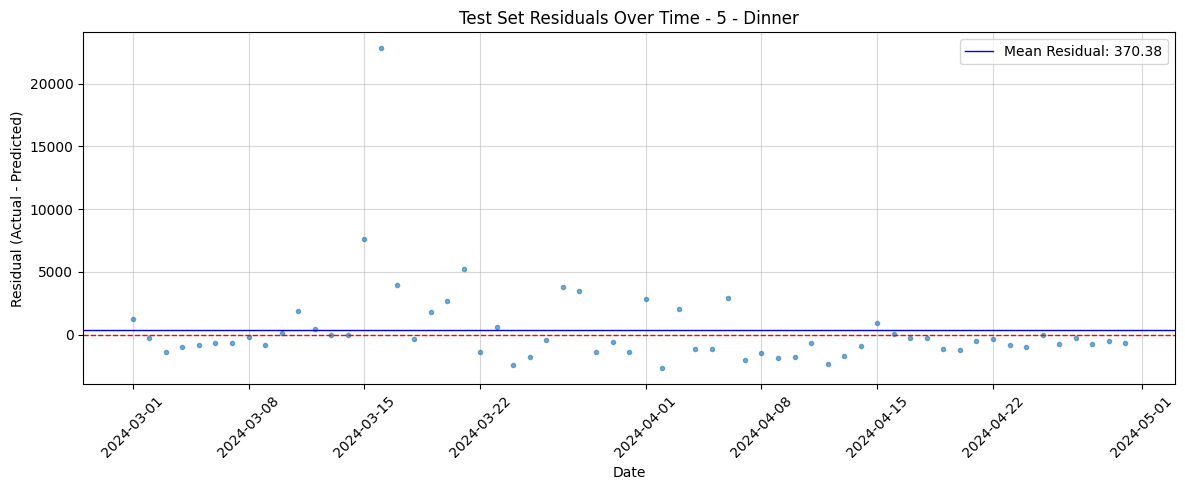


--- FINAL TEST SET RESULTS (5 - Lunch) ---
TEST RMSE: 1009.26, TEST MAPE: 1479810236.96%


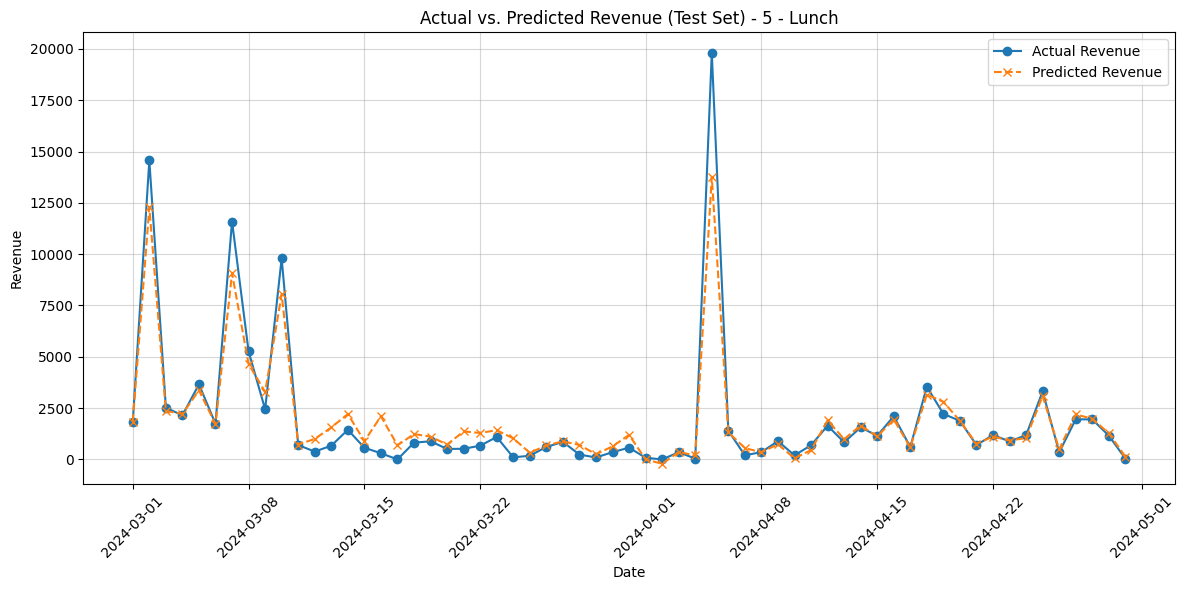

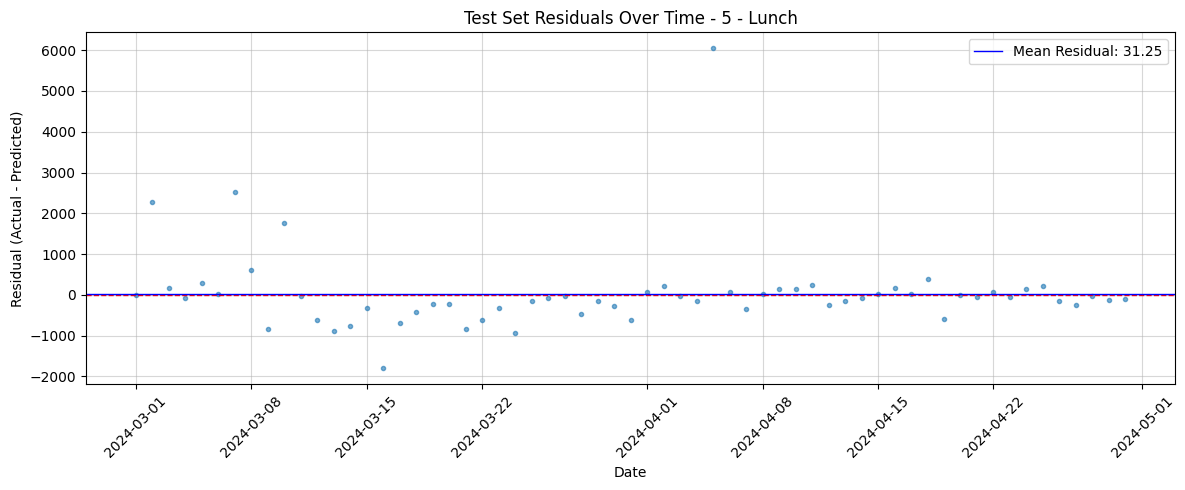


--- FINAL TEST SET RESULTS (6 - BreakFast) ---
TEST RMSE: 213.46, TEST MAPE: 877040638.76%


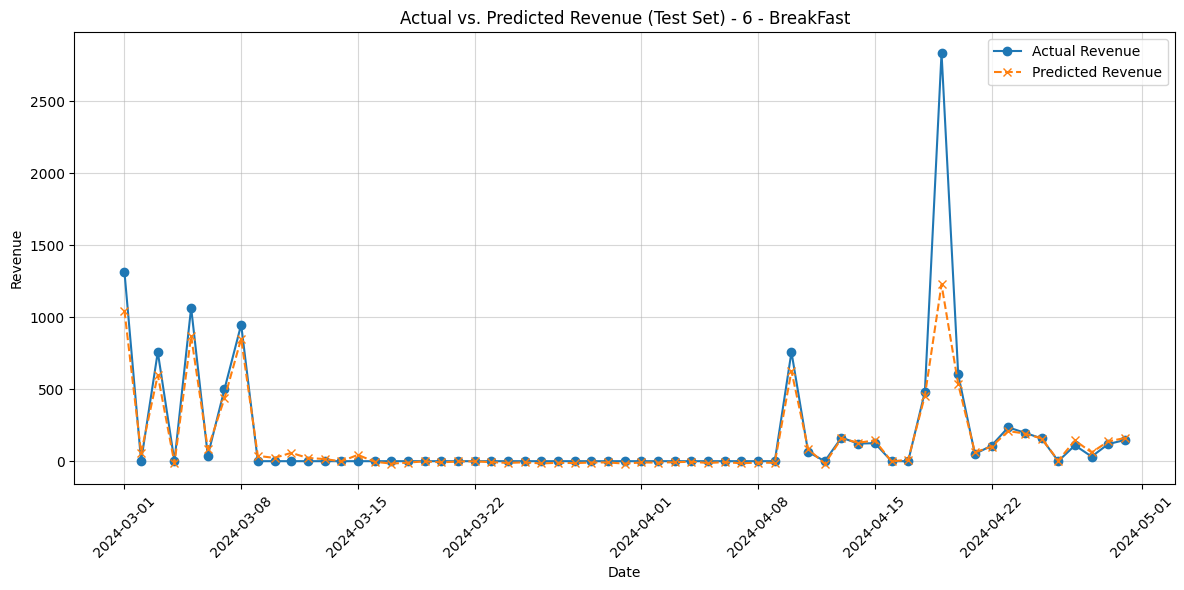

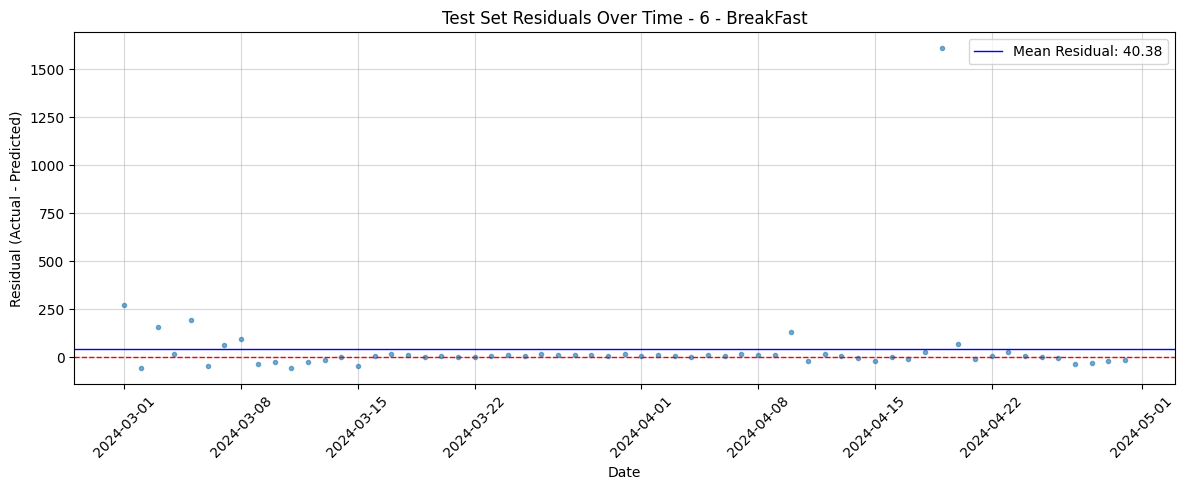


--- FINAL TEST SET RESULTS (6 - Dinner) ---
TEST RMSE: 5126.15, TEST MAPE: 7106876748.26%


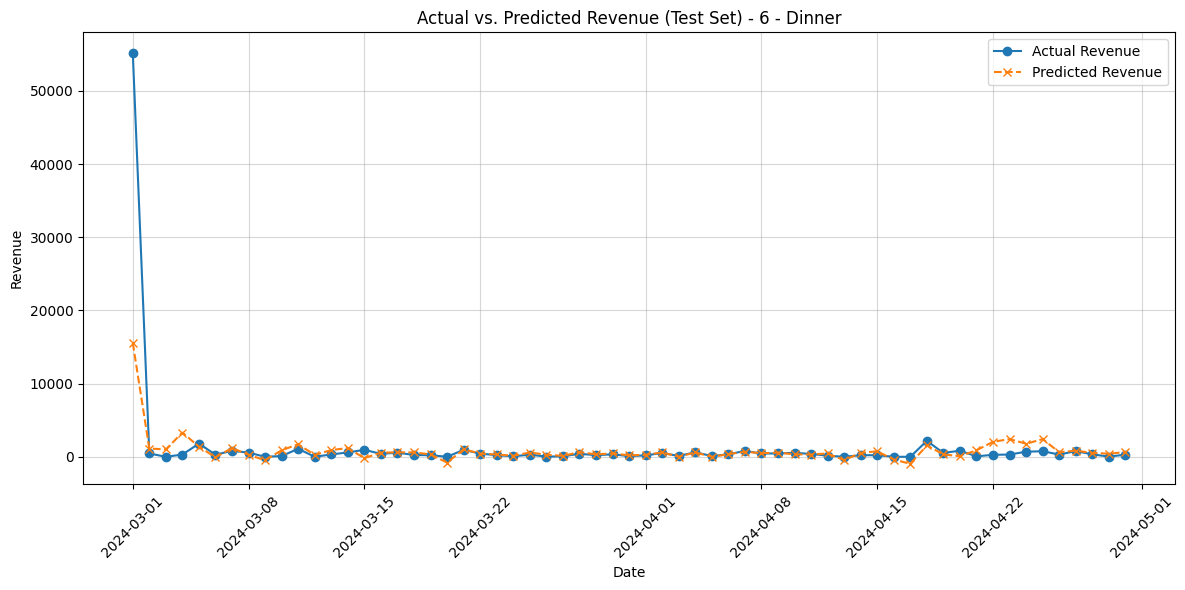

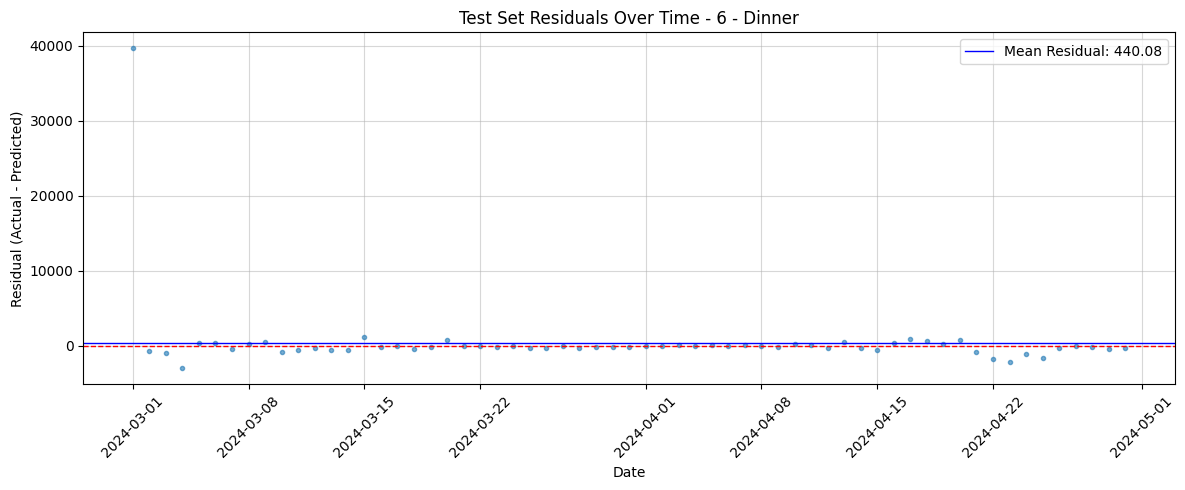


--- FINAL TEST SET RESULTS (6 - Lunch) ---
TEST RMSE: 298.32, TEST MAPE: 3478783576.99%


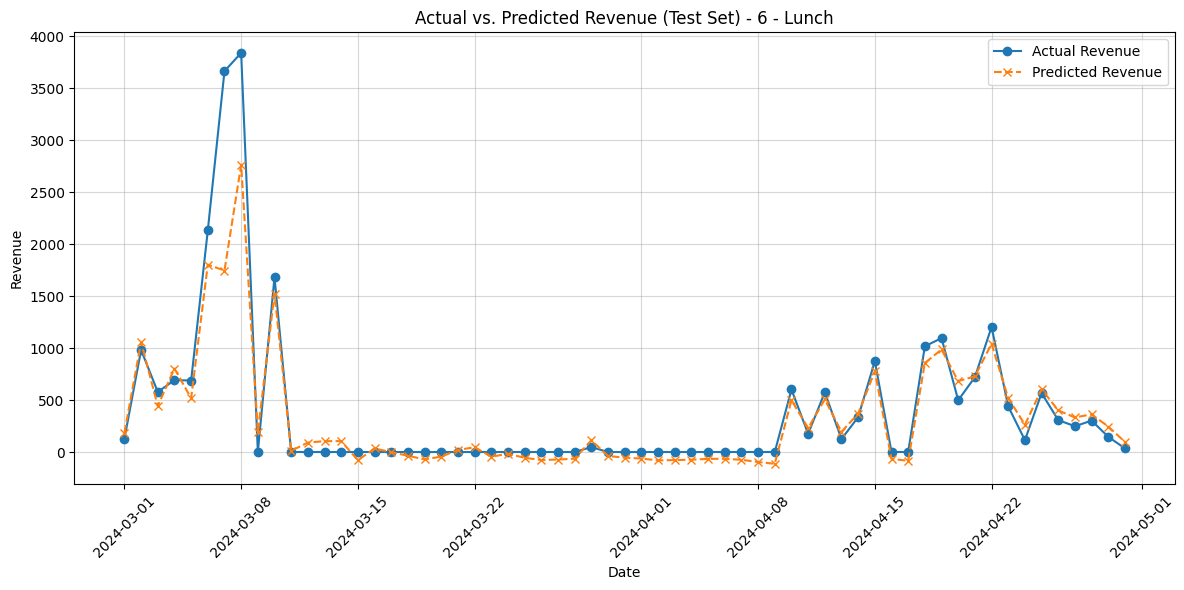

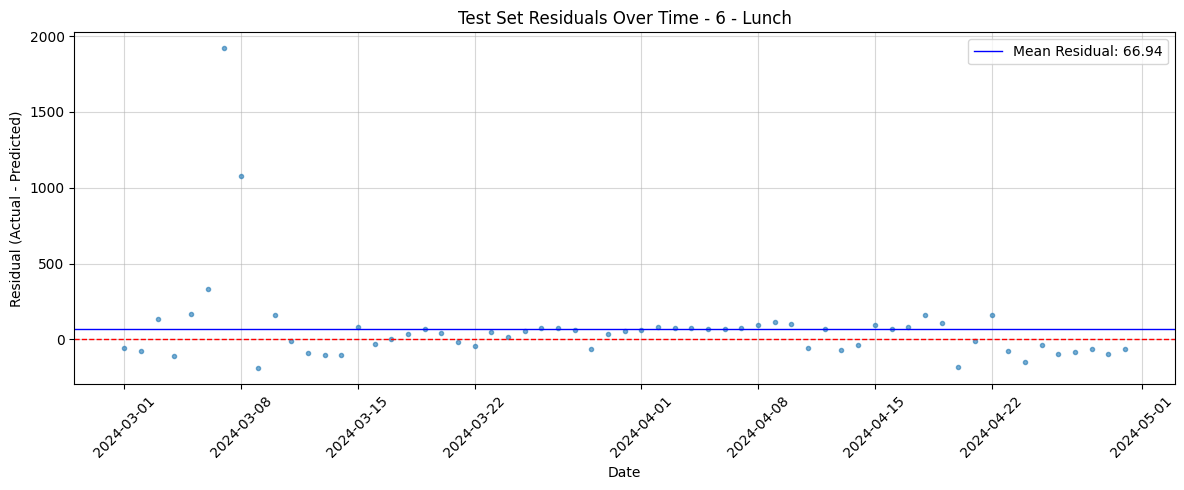


--- FINAL TEST SET RESULTS (7 - BreakFast) ---
TEST RMSE: 4.93, TEST MAPE: 173586306.77%


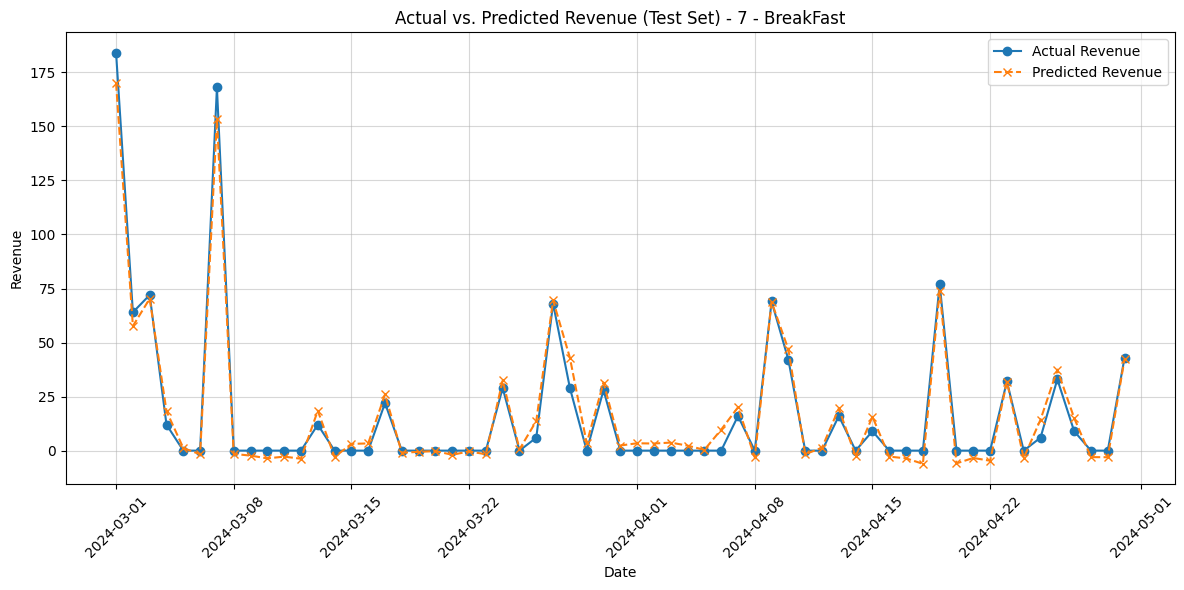

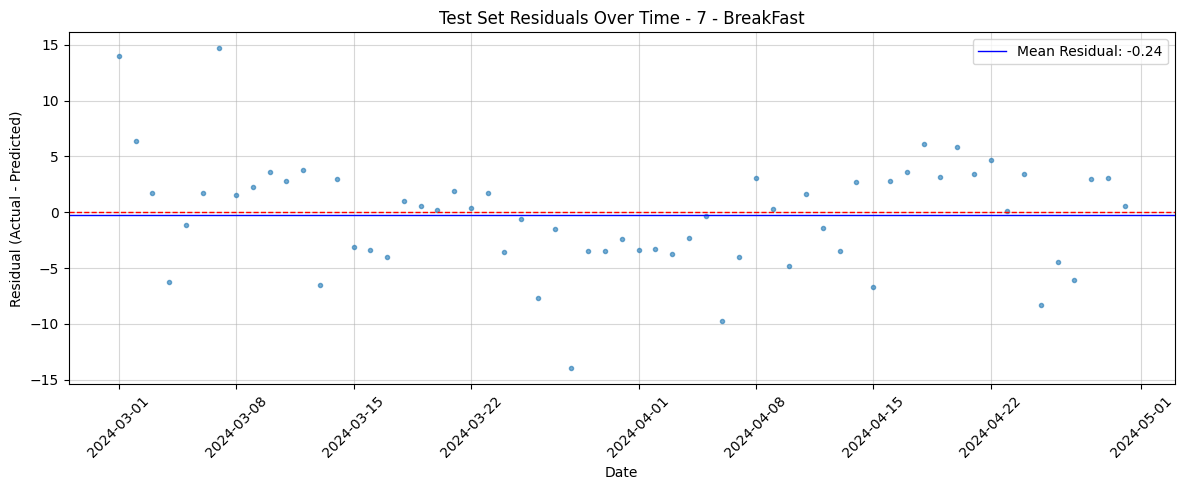


--- FINAL TEST SET RESULTS (7 - Dinner) ---
TEST RMSE: 66.84, TEST MAPE: 131400175.86%


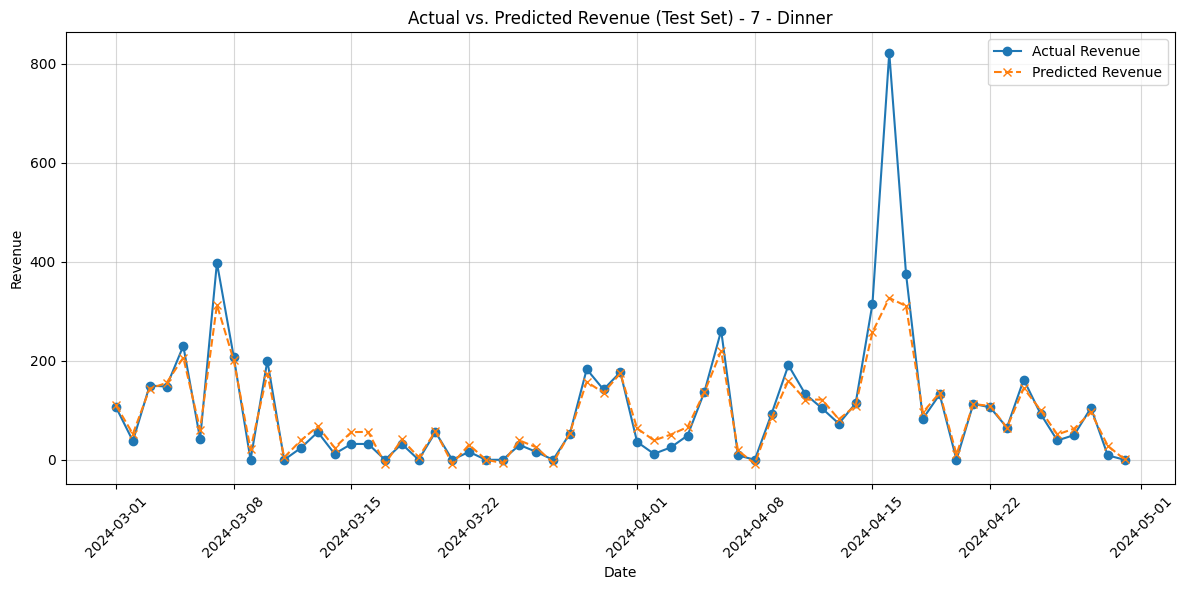

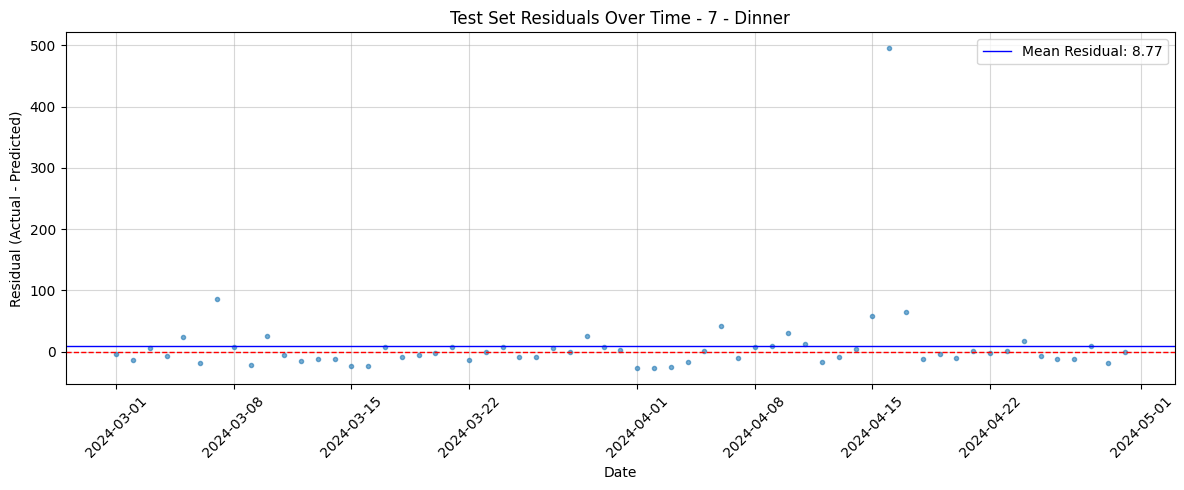


--- FINAL TEST SET RESULTS (7 - Lunch) ---
TEST RMSE: 20.49, TEST MAPE: 137766688.39%


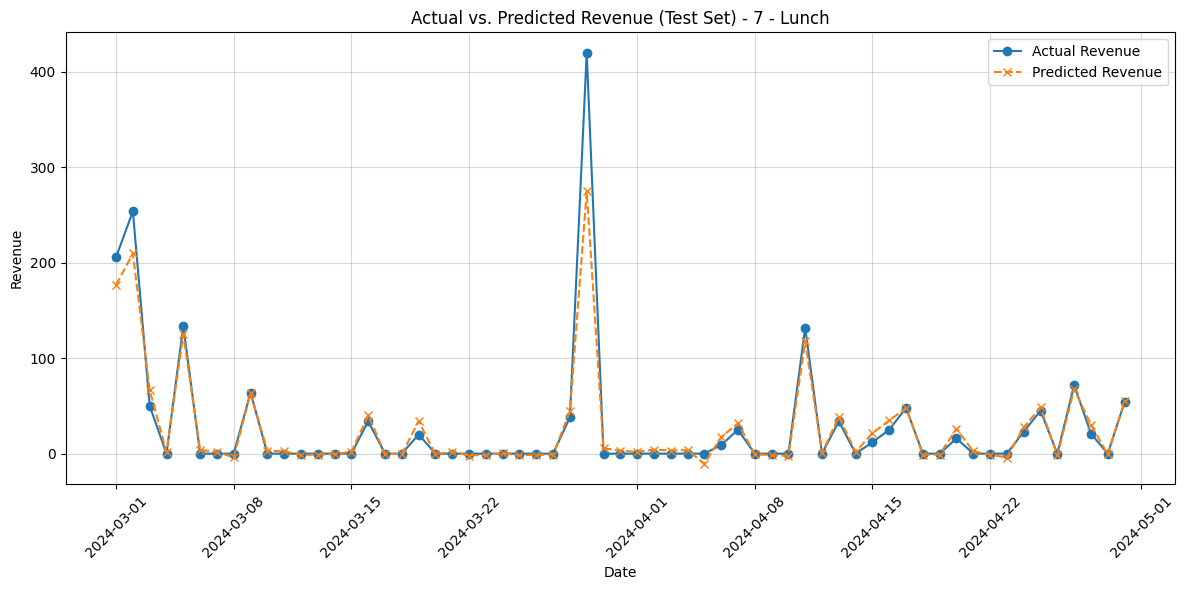

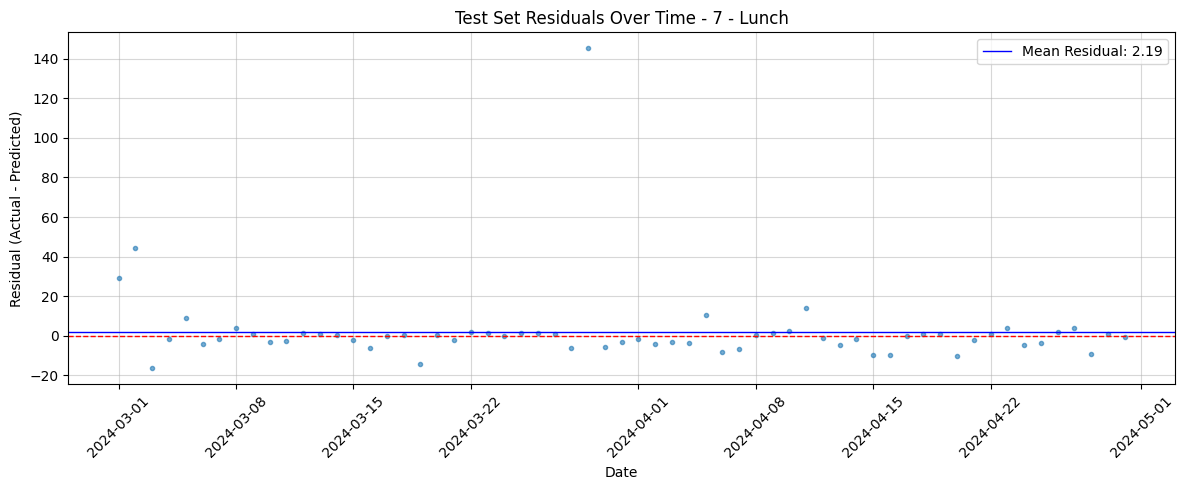


--- FINAL TEST SET RESULTS (8 - BreakFast) ---
TEST RMSE: 930.85, TEST MAPE: 12661580635.90%


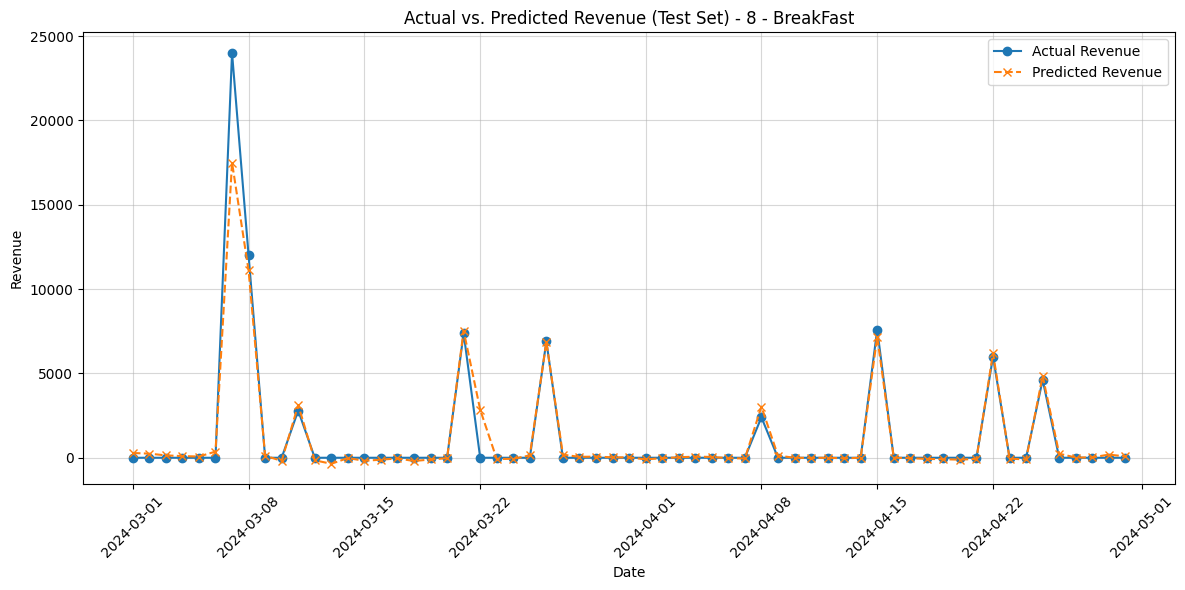

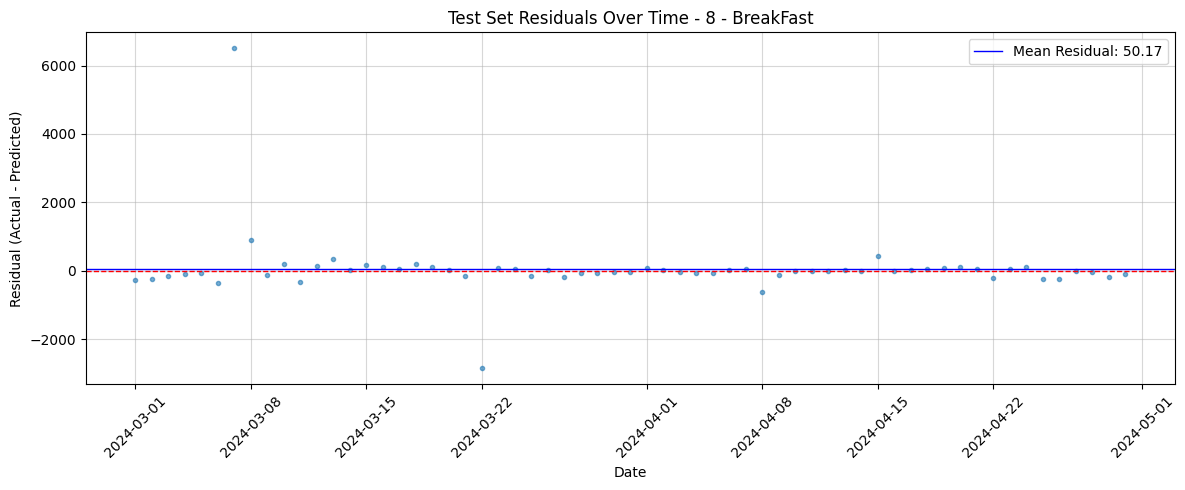


--- FINAL TEST SET RESULTS (8 - Dinner) ---
TEST RMSE: 6587.97, TEST MAPE: 52303639922.15%


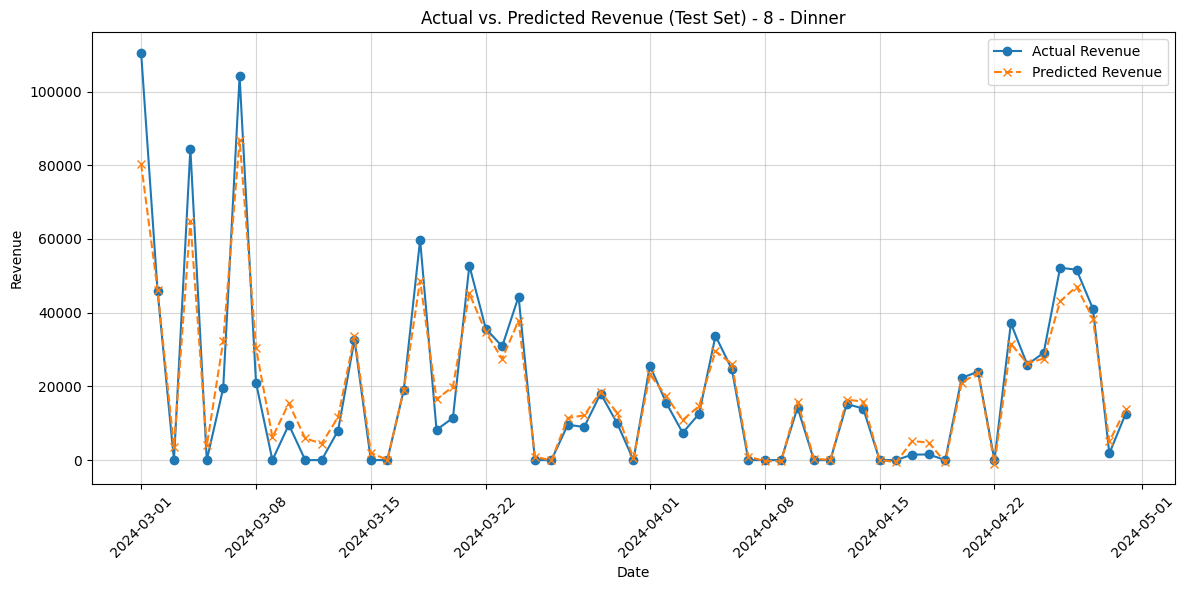

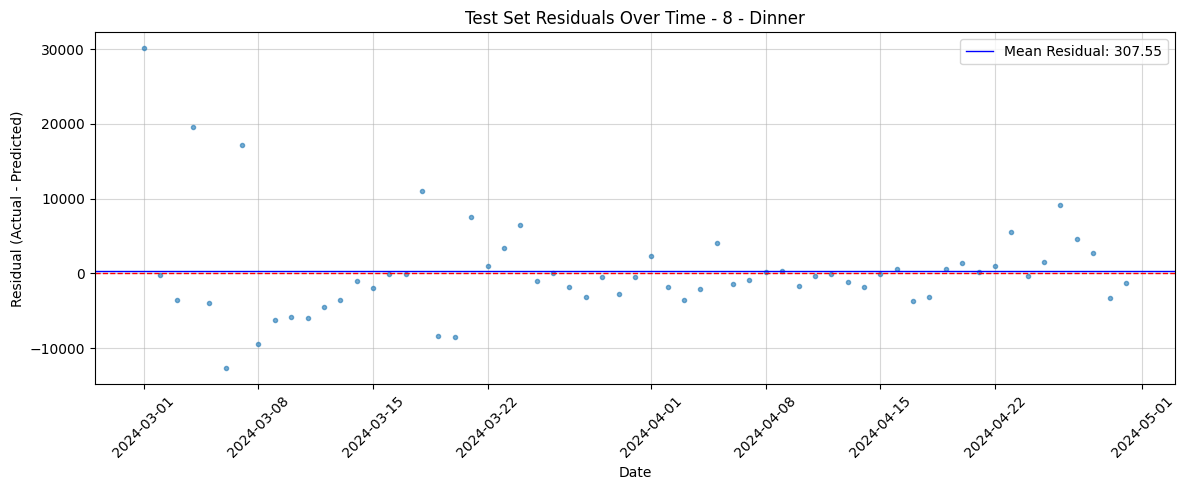


--- FINAL TEST SET RESULTS (8 - Lunch) ---
TEST RMSE: 7303.07, TEST MAPE: 47717473292.92%


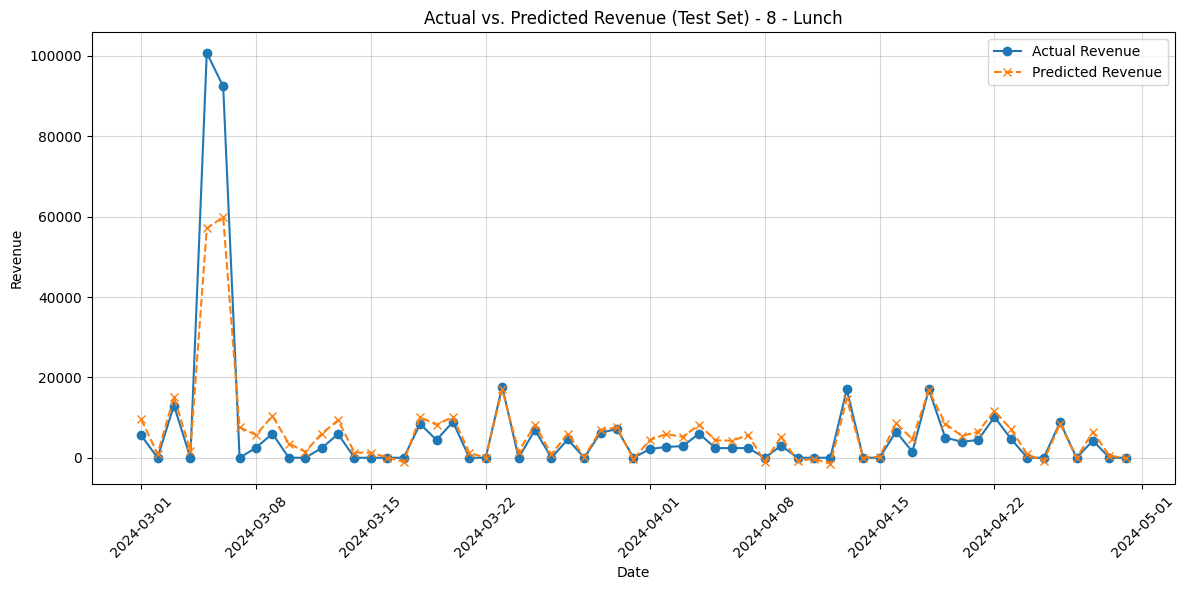

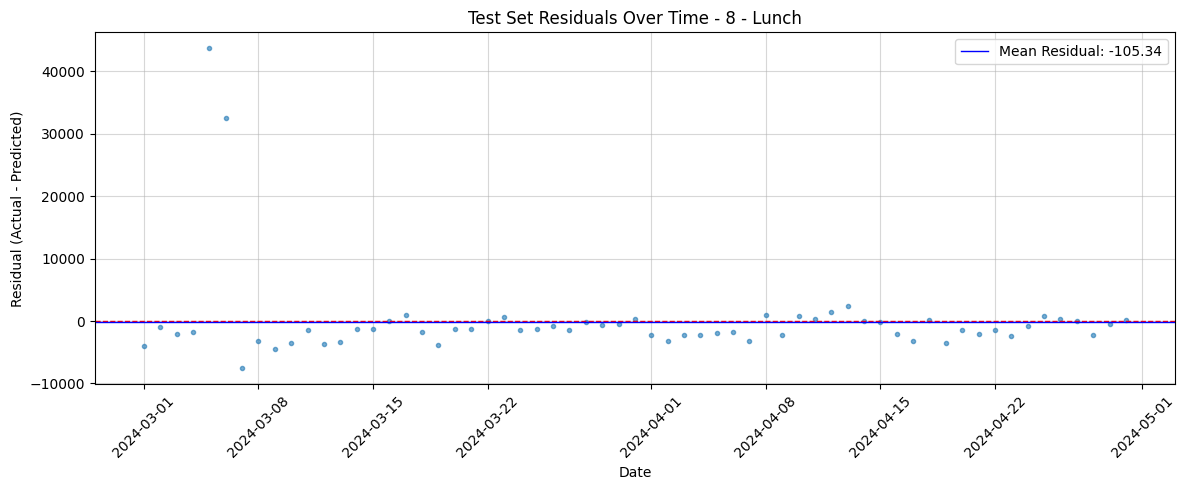


--- FINAL TEST SET RESULTS (9 - BreakFast) ---
TEST RMSE: 102.01, TEST MAPE: 313220267.76%


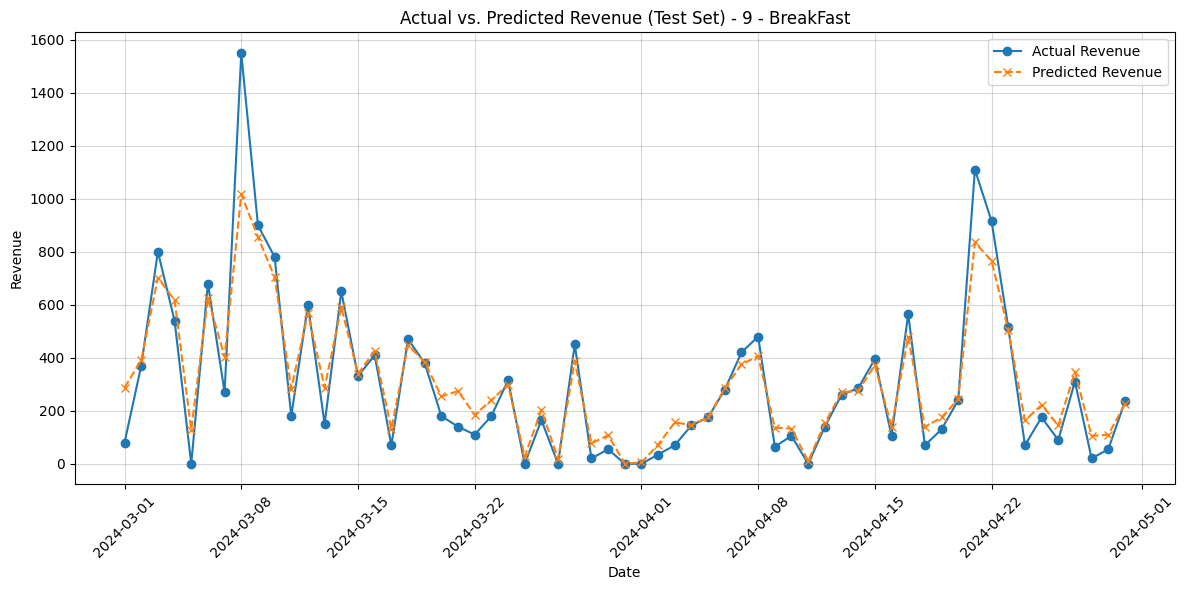

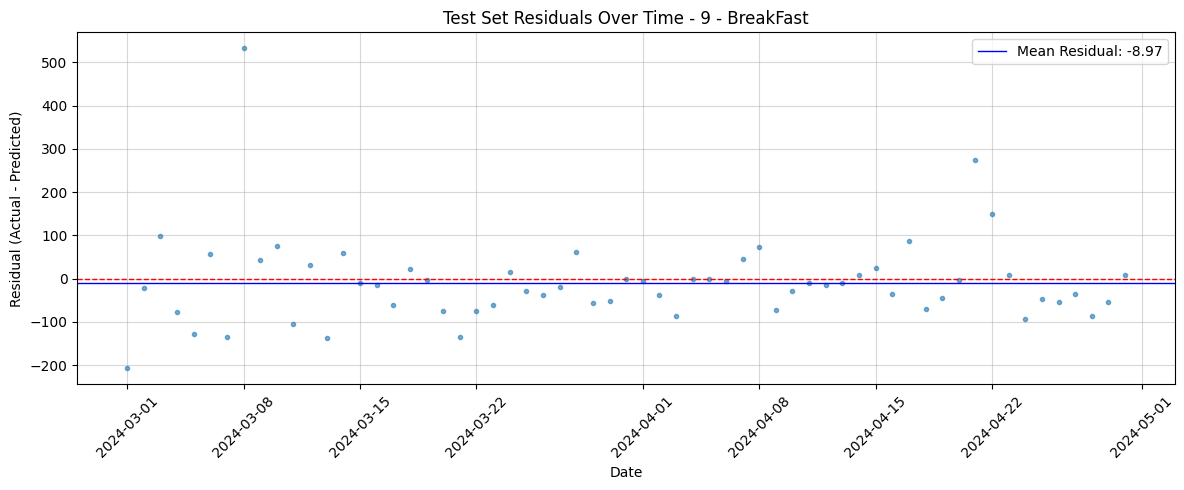


--- FINAL TEST SET RESULTS (9 - Dinner) ---
TEST RMSE: 59.74, TEST MAPE: 529851619.89%


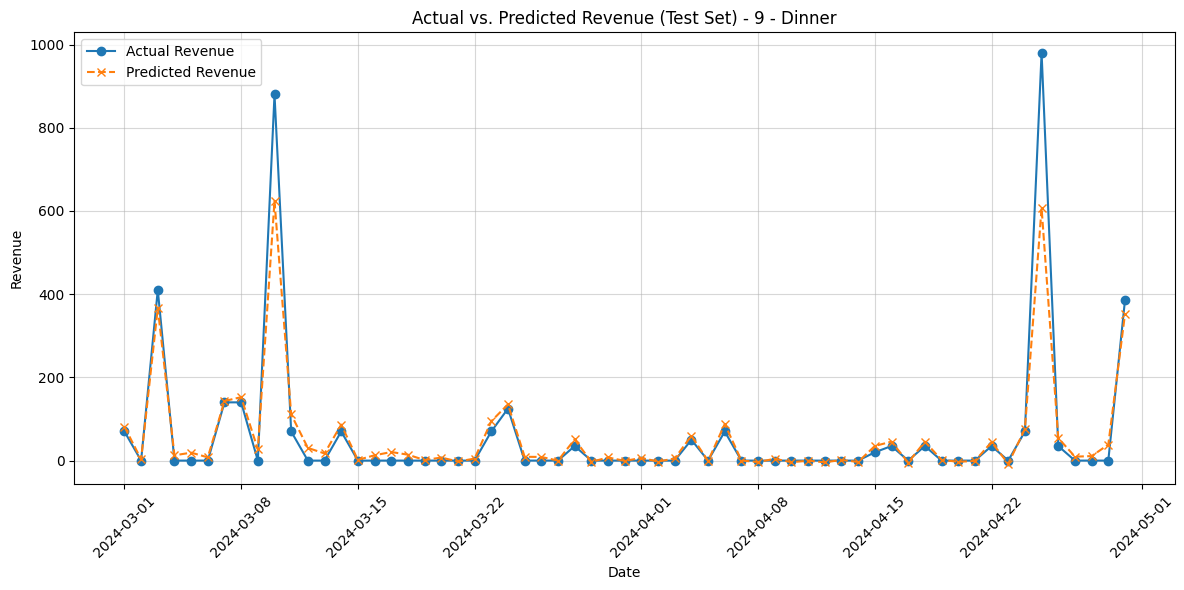

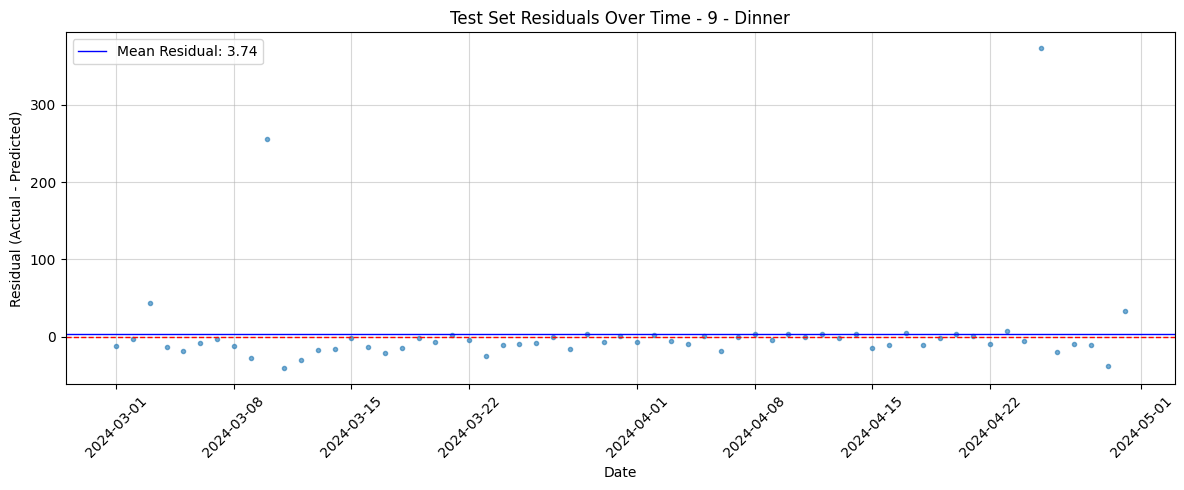


--- FINAL TEST SET RESULTS (9 - Lunch) ---
TEST RMSE: 31.80, TEST MAPE: 98052835.31%


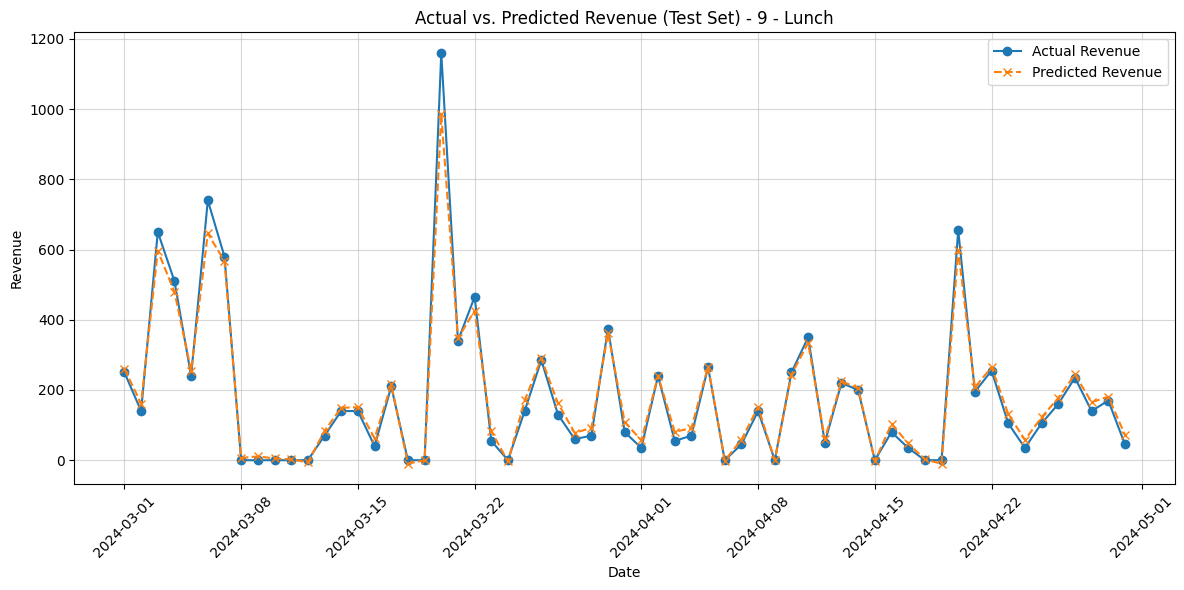

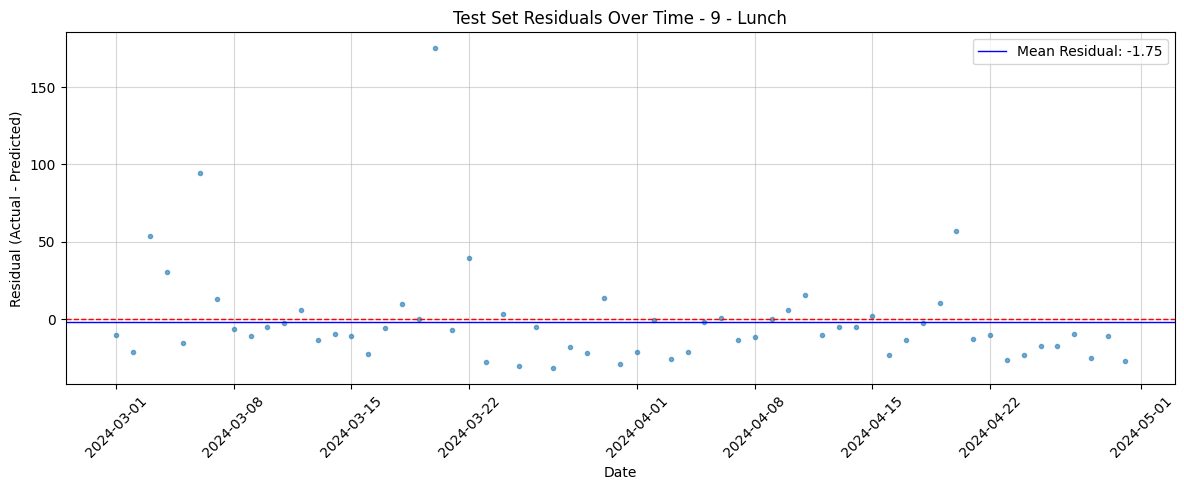


--- POST-TRAINING DIAGNOSTICS ---

--- VISUALIZING CROSS-VALIDATION ROBUSTNESS ---


<Figure size 1400x700 with 0 Axes>

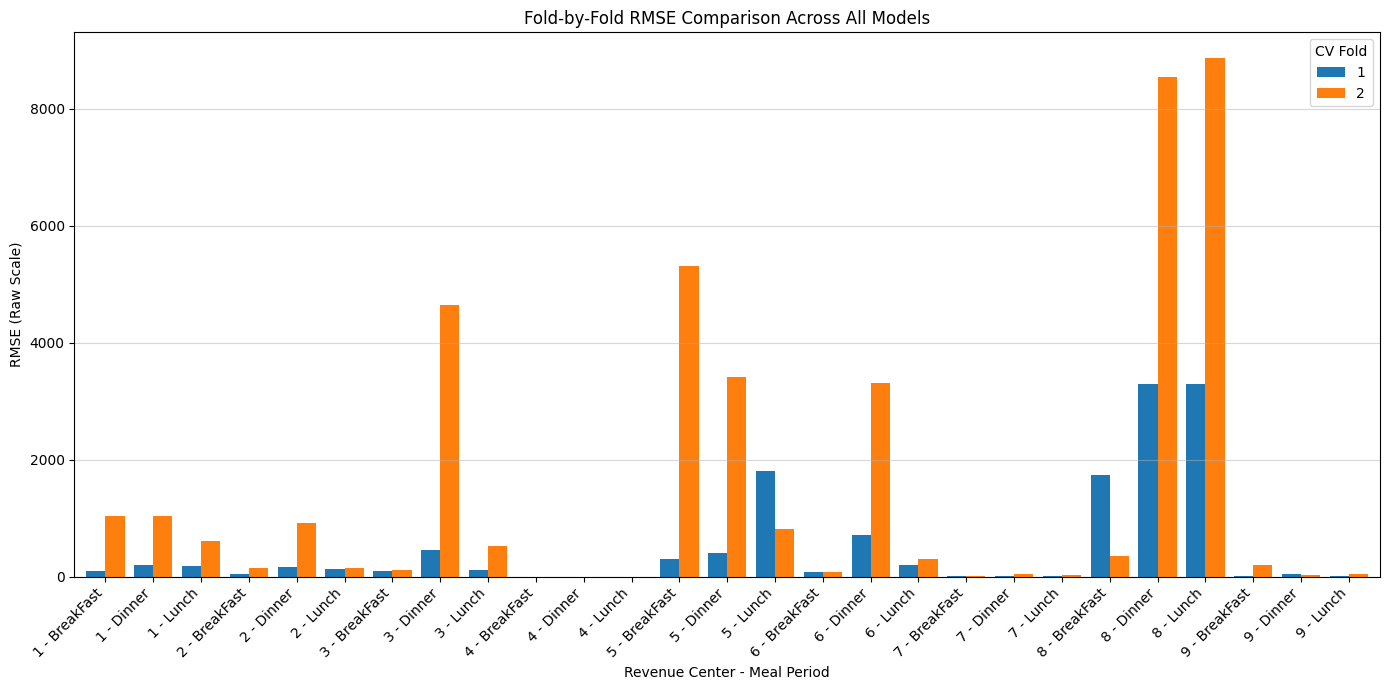


--- FEATURE IMPORTANCE SAMPLE (Top 10) ---
Log_Revenue_Breakfast             9470.0
Log_Revenue_Dinner                2143.0
Log_Revenue_Lunch                 2013.0
Revenue_By_Lunch_lag1             1415.0
Revenue_By_BreakFast_rollmean7    1326.0
Revenue_By_Lunch_rollmean7        1255.0
Revenue_By_BreakFast_rollstd7     1108.0
Revenue_By_BreakFast_lag1         1081.0
Revenue_By_Dinner_lag1            1066.0
Revenue_By_Dinner_rollmean7       1061.0
dtype: float64


In [57]:
# --- Execute Training Across Centers ---

print("--- STARTING EXECUTION ---")
try:
    if not os.path.exists(OUTPUT_FILE_NAME):
        raise FileNotFoundError(f"File not found at path: {OUTPUT_FILE_NAME}")
    xls = pd.ExcelFile(OUTPUT_FILE_NAME)
    REVENUE_CENTERS = xls.sheet_names
    print(f"✅ SUCCESS: Loaded {len(REVENUE_CENTERS)} revenue centers (sheets).")
except FileNotFoundError as e:
    print(f"❌ ERROR: File Not Found. Please check the path and ensure the file is uploaded/mounted. {e}")
    REVENUE_CENTERS = []
except Exception as e:
    print(f"❌ ERROR loading Excel file: {e}")
    REVENUE_CENTERS = []

for center_name in REVENUE_CENTERS:
    df_center = pd.read_excel(OUTPUT_FILE_NAME, sheet_name=center_name)
    df_center['Date'] = pd.to_datetime(df_center['Date'])
    required_cols = ['Date'] + TARGET_RAW_COLS
    if not all(col in df_center.columns for col in required_cols):
        print(f"❌ FAILED: Center {center_name} is missing essential columns. Skipping.")
        continue
    train_and_forecast_center(df_center, center_name)

# --- Post-Training Diagnostics ---
if REVENUE_CENTERS:
    print("\n--- POST-TRAINING DIAGNOSTICS ---")
    print("\n--- VISUALIZING CROSS-VALIDATION ROBUSTNESS ---")
    plot_cv_rmse_comparison(cv_results_list)
    if feature_importance_dict:
        print("\n--- FEATURE IMPORTANCE SAMPLE (Top 10) ---")
        sample_key = list(feature_importance_dict.keys())[0]
        # Convert keys to readable format if necessary
        fi_sample = feature_importance_dict[sample_key]
        if isinstance(fi_sample, pd.Series):
            print(fi_sample.head(10))
        else:
            print(pd.Series(fi_sample).sort_values(ascending=False).head(10))